# Same-area and multiscale provider acquisition checks

This notebook asks two operational questions: how coverage differs between providers over identical WGS84 bounds, and which levels remain usable for the same provider at a fixed covered location. It covers all 16 implemented paths. Network access is disabled by default; raw responses and figures stay under the ignored `local/` directory.


In [1]:
import math
import os
import shutil
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch, Rectangle


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "coverage_acquisition").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the shared-dev repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "integrations" / "mappls_realview" / "src"))

from mappls_realview.bbox import BBox as MapplsBBox
from mappls_realview.bbox import tiles_for_bbox as mappls_tiles_for_bbox
from mappls_realview.sdk_capture import capture_sdk_bbox_async

from coverage_acquisition.case_studies import (
    AREA_COMPARISON_CASES,
    MAPPLS_KEY,
    MULTISCALE_CASES,
    MULTISCALE_LEVELS,
    PROVIDER_LABELS,
    TENCENT_KEY,
    area_case,
    multiscale_case,
    multiscale_plan,
    multiscale_probe_bbox,
    validate_case_contract,
    validate_multiscale_probe,
)
from coverage_acquisition.geo import tile_range_for_bbox
from coverage_acquisition.models import FetchAreaRequest
from coverage_acquisition.providers import PROVIDERS
from coverage_acquisition.runners import fetch_provider_coverage
from coverage_acquisition.tencent_pmtiles import (
    DEFAULT_TENCENT_PMTILES_URL,
    fetch_tencent_pmtiles_sv_coverage,
)
from coverage_acquisition.visualization import (
    load_mappls_segments,
    load_result_from_manifest,
    plot_mappls_segments,
    plot_result,
    result_tile_bbox,
    style_geo_axis,
)

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "font.size": 7,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)

## Controls

Add individual `(case, provider)` or `(provider, level)` pairs only after reviewing authorization and request size. Access-gated providers also require explicit authorization below.


In [2]:
ALLOW_NETWORK = os.getenv("SVI_NOTEBOOK_ALLOW_NETWORK") == "1"
SHOW_REFERENCE_MAPS = os.getenv("SVI_SHOW_REFERENCE_MAPS") == "1"
CAPTURE_BARIKOI_MAPS = os.getenv("SVI_CAPTURE_BARIKOI_MAPS") == "1"
RUN_ACQUISITIONS: set[tuple[str, str]] = set()
RUN_MULTISCALE_PROBES: set[tuple[str, int]] = set()
AUTHORIZED_ACCESS_GATED: set[str] = set()
RENDER_CASES: tuple[str, ...] = ()
FOCAL_MULTISCALE_PROVIDER = "barikoi"

OUTPUT_ROOT = PROJECT_ROOT / "local" / "provider_comparison_cases"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
REFERENCE_FIGURE_ROOT = OUTPUT_ROOT / "reference_figures"
MAPILLARY_ACCESS_TOKEN = os.getenv("MAPILLARY_ACCESS_TOKEN")
TENCENT_PMTILES_URL = os.getenv("TENCENT_PMTILES_URL", DEFAULT_TENCENT_PMTILES_URL)

## 1. Same-area, cross-provider comparison

The case contract retains the existing bounds and source selections. Requested and effective source levels are kept separate; Kakao uses native L-level semantics.


In [3]:
validate_case_contract()
case_rows = []
for case in AREA_COMPARISON_CASES:
    for item in case.providers:
        semantics = "native L" if item.provider == "kakao" else "z"
        case_rows.append(
            {
                "case": case.key,
                "area": case.label,
                "provider": PROVIDER_LABELS[item.provider],
                "provider_key": item.provider,
                "requested_level": f"{semantics}{item.requested_level}",
                "bbox_wgs84": tuple(case.bbox.as_dict().values()),
            }
        )

case_df = pd.DataFrame(case_rows)
assert case_df["provider_key"].nunique() == 16
display(case_df)

,case,area,provider,provider_key,requested_level,bbox_wgs84
0,shenzhen_futian,Shenzhen Futian,Baidu,baidu,z18,"(114.02, 22.5, 114.08, 22.56)"
1,shenzhen_futian,Shenzhen Futian,Tencent Street View,tencent_pmtiles_sv,z12,"(114.02, 22.5, 114.08, 22.56)"
2,hong_kong_core,Hong Kong Island + Kowloon,Google Street View,svmap_google,z13,"(114.1, 22.25, 114.25, 22.35)"
3,hong_kong_core,Hong Kong Island + Kowloon,Apple Look Around,apple_lookaround,z13,"(114.1, 22.25, 114.25, 22.35)"
4,hong_kong_core,Hong Kong Island + Kowloon,Baidu,baidu,z13,"(114.1, 22.25, 114.25, 22.35)"
5,hong_kong_core,Hong Kong Island + Kowloon,Tencent Street View,tencent_pmtiles_sv,z12,"(114.1, 22.25, 114.25, 22.35)"
6,seoul_center,Central Seoul,Google Street View,svmap_google,z15,"(126.965, 37.555, 127.005, 37.585)"
7,seoul_center,Central Seoul,Naver,naver,z15,"(126.965, 37.555, 127.005, 37.585)"
8,seoul_center,Central Seoul,Kakao,kakao,native L5,"(126.965, 37.555, 127.005, 37.585)"
9,chiang_mai,Chiang Mai,Google Street View,svmap_google,z14,"(98.899549, 18.697236, 99.073957, 18.864633)"


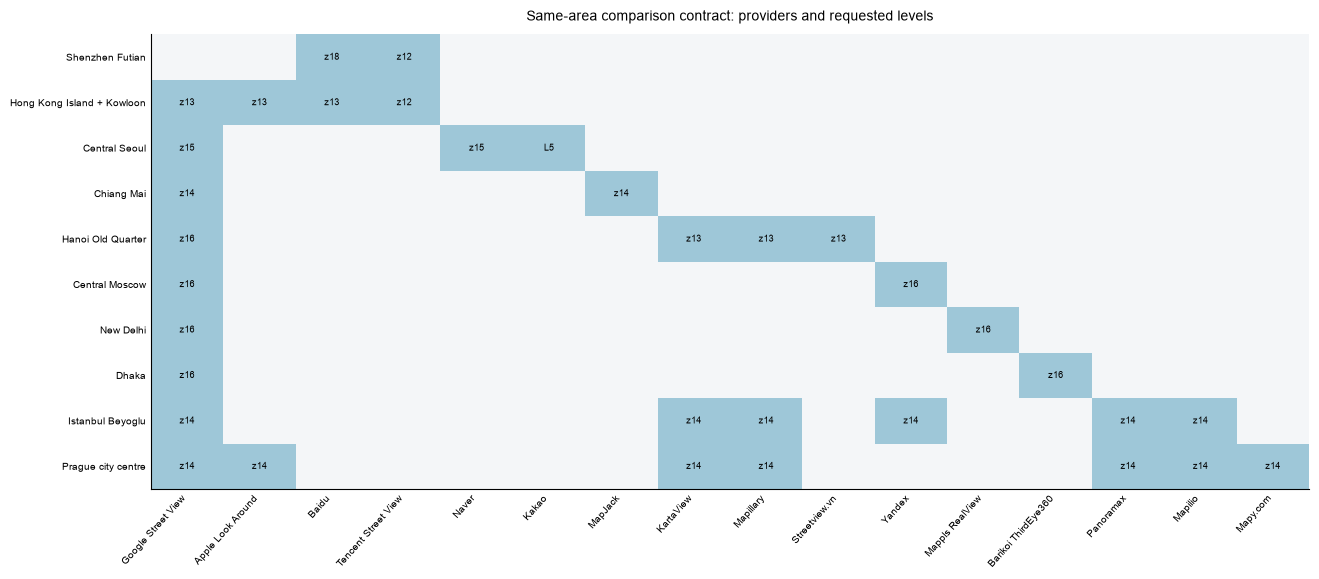

In [4]:
provider_order = [case.provider for case in MULTISCALE_CASES]
provider_index = {provider: index for index, provider in enumerate(provider_order)}
matrix = np.zeros((len(AREA_COMPARISON_CASES), len(provider_order)), dtype=int)
labels = np.full(matrix.shape, "", dtype=object)
for row_index, case in enumerate(AREA_COMPARISON_CASES):
    for item in case.providers:
        column_index = provider_index[item.provider]
        matrix[row_index, column_index] = 1
        prefix = "L" if item.provider == "kakao" else "z"
        labels[row_index, column_index] = f"{prefix}{item.requested_level}"

fig, ax = plt.subplots(figsize=(13.2, 5.8))
ax.imshow(matrix, cmap=ListedColormap(["#F4F6F8", "#9EC7D8"]), vmin=0, vmax=1, aspect="auto")
for row_index in range(matrix.shape[0]):
    for column_index in range(matrix.shape[1]):
        if labels[row_index, column_index]:
            ax.text(column_index, row_index, labels[row_index, column_index], ha="center", va="center", fontsize=6.2)
ax.set_xticks(range(len(provider_order)), [PROVIDER_LABELS[key] for key in provider_order], rotation=48, ha="right")
ax.set_yticks(range(len(AREA_COMPARISON_CASES)), [case.label for case in AREA_COMPARISON_CASES])
ax.set_title("Same-area comparison contract: providers and requested levels", fontsize=10, pad=10)
ax.tick_params(length=0)
fig.tight_layout()
plt.show()

In [5]:
def plan_area_request(case, item):
    if item.provider in PROVIDERS:
        result = fetch_provider_coverage(
            FetchAreaRequest(
                provider=item.provider,
                bbox=case.bbox,
                output_root=OUTPUT_ROOT,
                display_zoom=item.requested_level,
                dry_run=True,
            )
        )
        job = result["jobs"][0]
        return {
            "case": case.key,
            "provider": item.provider,
            "requested_level": item.requested_level,
            "effective_source_level": job["source_zoom"],
            "source_id": job["source"].id,
            "source_kind": job["source"].kind,
            "planned_tiles": job["source_tile_count"],
            "plan_status": "dry_run",
        }
    if item.provider == TENCENT_KEY:
        tile_range = tile_range_for_bbox(case.bbox, item.requested_level, "web_mercator")
        return {
            "case": case.key,
            "provider": item.provider,
            "requested_level": item.requested_level,
            "effective_source_level": item.requested_level,
            "source_id": "qq_map_lines_pmtiles_sv",
            "source_kind": "vector_mvt",
            "planned_tiles": tile_range.count,
            "plan_status": "archive_plan",
        }
    west, south, east, north = case.bbox.as_dict().values()
    count = len(mappls_tiles_for_bbox(MapplsBBox(west, south, east, north), item.requested_level))
    return {
        "case": case.key,
        "provider": item.provider,
        "requested_level": item.requested_level,
        "effective_source_level": item.requested_level,
        "source_id": "mappls_realview_sdk",
        "source_kind": "vector_mvt",
        "planned_tiles": count,
        "plan_status": "access_gated",
    }


area_plan_df = pd.DataFrame(
    [plan_area_request(case, item) for case in AREA_COMPARISON_CASES for item in case.providers]
)
display(area_plan_df)

,case,provider,requested_level,effective_source_level,source_id,source_kind,planned_tiles,plan_status
0,shenzhen_futian,baidu,18,18,baidu_mapsv_tile,raster,783,dry_run
1,shenzhen_futian,tencent_pmtiles_sv,12,12,qq_map_lines_pmtiles_sv,vector_mvt,2,archive_plan
2,hong_kong_core,svmap_google,13,13,svmap_google_mts,raster,12,dry_run
3,hong_kong_core,apple_lookaround,13,13,apple_lookaround_cached_bluelines,vector_mvt,12,dry_run
4,hong_kong_core,baidu,13,13,baidu_mapsv_tile,raster,6,dry_run
5,hong_kong_core,tencent_pmtiles_sv,12,12,qq_map_lines_pmtiles_sv,vector_mvt,4,archive_plan
6,seoul_center,svmap_google,15,15,svmap_google_mts,raster,20,dry_run
7,seoul_center,naver,15,15,naver_streetview_overlay_png,raster,20,dry_run
8,seoul_center,kakao,5,5,kakao_roadviewline,raster,20,dry_run
9,chiang_mai,svmap_google,14,14,svmap_google_mts,raster,72,dry_run


In [6]:
def provider_level_for_case(case_key: str, provider_key: str):
    case = area_case(case_key)
    for item in case.providers:
        if item.provider == provider_key:
            return case, item
    raise KeyError(f"{provider_key} is not configured for {case_key}")


async def acquire_area_case(case_key: str, provider_key: str):
    if not ALLOW_NETWORK:
        raise RuntimeError("Set ALLOW_NETWORK=True before running an acquisition.")
    case, item = provider_level_for_case(case_key, provider_key)
    if provider_key in {"apple_lookaround", MAPPLS_KEY} and provider_key not in AUTHORIZED_ACCESS_GATED:
        raise PermissionError(f"Add {provider_key!r} to AUTHORIZED_ACCESS_GATED after authorization review.")
    run_label = f"{case.key}_{provider_key}"
    if provider_key in PROVIDERS:
        if provider_key == "mapillary" and not MAPILLARY_ACCESS_TOKEN:
            raise RuntimeError("Set MAPILLARY_ACCESS_TOKEN in the environment.")
        return fetch_provider_coverage(
            FetchAreaRequest(
                provider=provider_key,
                bbox=case.bbox,
                output_root=OUTPUT_ROOT,
                display_zoom=item.requested_level,
                stop_on_error=False,
                timeout_seconds=30,
                run_label=run_label,
                access_token=MAPILLARY_ACCESS_TOKEN if provider_key == "mapillary" else None,
            )
        )
    if provider_key == TENCENT_KEY:
        return fetch_tencent_pmtiles_sv_coverage(
            case.bbox,
            output_root=OUTPUT_ROOT,
            cache_dir=OUTPUT_ROOT / "tencent_pmtiles_cache",
            source_url=TENCENT_PMTILES_URL,
            source_zoom=item.requested_level,
            run_label=f"{run_label}_subbox_00",
        )
    bbox = MapplsBBox(case.bbox.min_lon, case.bbox.min_lat, case.bbox.max_lon, case.bbox.max_lat)
    return await capture_sdk_bbox_async(
        web_dir=PROJECT_ROOT / "integrations" / "mappls_realview" / "web",
        bbox=bbox,
        zoom=item.requested_level,
        out_dir=OUTPUT_ROOT / "mappls_realview",
        output_mode="production",
        run_id=f"{case.key}_mappls_z{item.requested_level}",
        headless=True,
    )


live_area_results = {}
for case_key, provider_key in sorted(RUN_ACQUISITIONS):
    live_area_results[(case_key, provider_key)] = await acquire_area_case(case_key, provider_key)
print(f"Live area acquisitions executed: {len(live_area_results)}")

Live area acquisitions executed: 0


In [7]:
def registry_manifest_path(case, provider_key):
    namespace = PROVIDERS[provider_key].output_namespace
    return OUTPUT_ROOT / namespace / f"{case.key}_{provider_key}_subbox_00" / "manifest.json"


def tencent_manifest_path(case):
    return OUTPUT_ROOT / TENCENT_KEY / f"{case.key}_{TENCENT_KEY}_subbox_00" / "manifest.json"


def mappls_summary_path(case, level):
    return OUTPUT_ROOT / "mappls_realview" / "production" / "runs" / f"{case.key}_mappls_z{level}.json"


def render_area_comparison(case_key: str):
    case = area_case(case_key)
    ncols = min(4, len(case.providers))
    nrows = math.ceil(len(case.providers) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)
    for ax, item in zip(axes.flat, case.providers):
        prefix = "L" if item.provider == "kakao" else "z"
        level_label = f"requested {prefix}{item.requested_level}"
        try:
            if item.provider in PROVIDERS:
                path = registry_manifest_path(case, item.provider)
                if not path.exists():
                    raise FileNotFoundError(path)
                plot_result(
                    ax,
                    load_result_from_manifest(path),
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
            elif item.provider == TENCENT_KEY:
                path = tencent_manifest_path(case)
                if not path.exists():
                    raise FileNotFoundError(path)
                plot_result(
                    ax,
                    load_result_from_manifest(path),
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
            else:
                path = mappls_summary_path(case, item.requested_level)
                if not path.exists():
                    raise FileNotFoundError(path)
                returned_bbox, segments = load_mappls_segments(path)
                if returned_bbox.as_dict() != case.bbox.as_dict():
                    raise RuntimeError("Mappls returned different bounds.")
                plot_mappls_segments(
                    ax,
                    segments,
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
        except FileNotFoundError:
            style_geo_axis(ax, case.bbox, f"{PROVIDER_LABELS[item.provider]}\n{level_label}; not acquired")
            ax.text(0.5, 0.5, "not acquired", transform=ax.transAxes, ha="center", va="center", color="#7A8793")
    for ax in axes.flat[len(case.providers) :]:
        ax.axis("off")
    fig.suptitle(f"{case.label}: provider coverage over identical WGS84 bounds", fontsize=10, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig


for case_key in RENDER_CASES:
    render_area_comparison(case_key)
    plt.show()
if not RENDER_CASES:
    print("No map panels rendered. Add a case key to RENDER_CASES after acquisition or cache review.")

No map panels rendered. Add a case key to RENDER_CASES after acquisition or cache review.


### Validated same-area map outputs

The rendered outputs below retain the actual provider coverage maps from the validated comparison run. They are embedded in this notebook for collaborators; raw tiles are intentionally excluded from the repository.


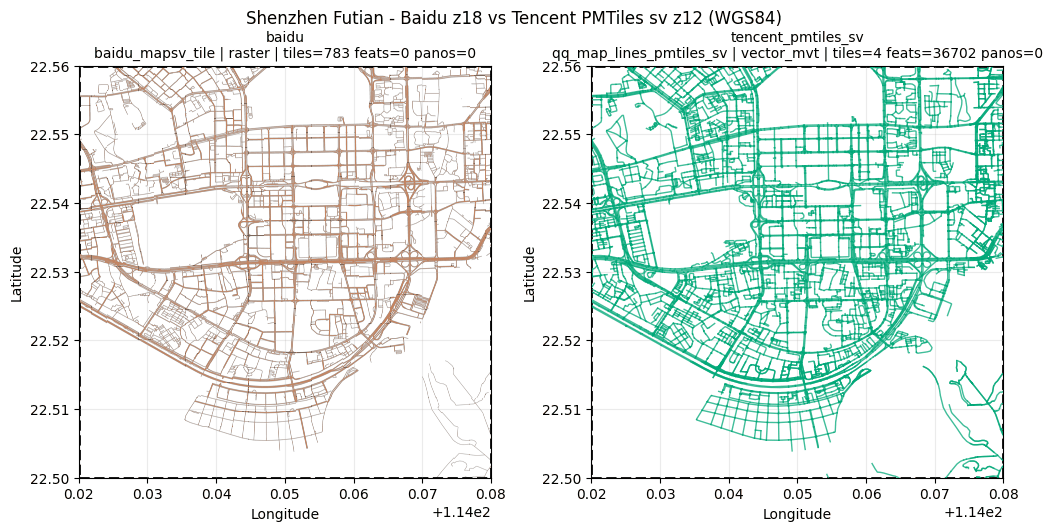

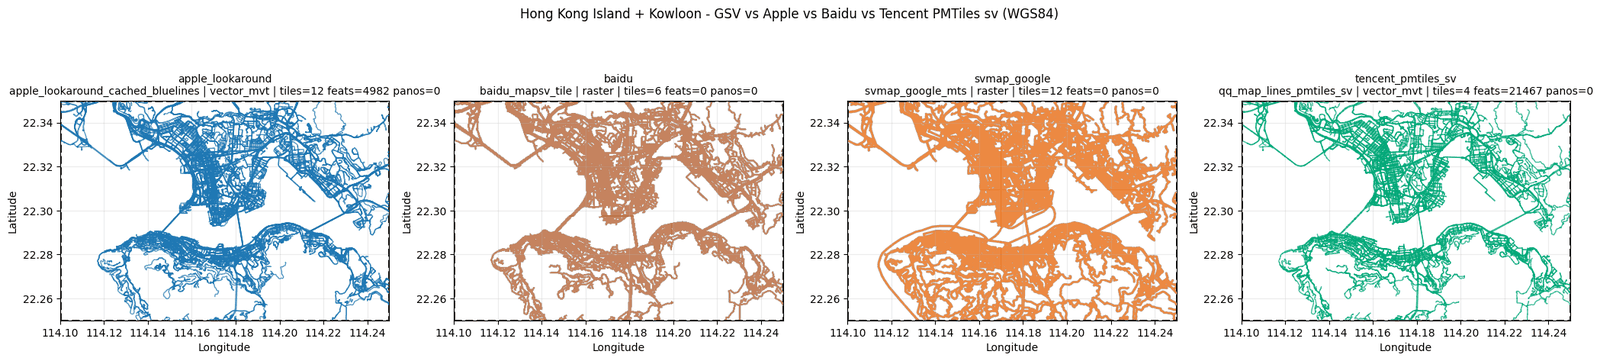

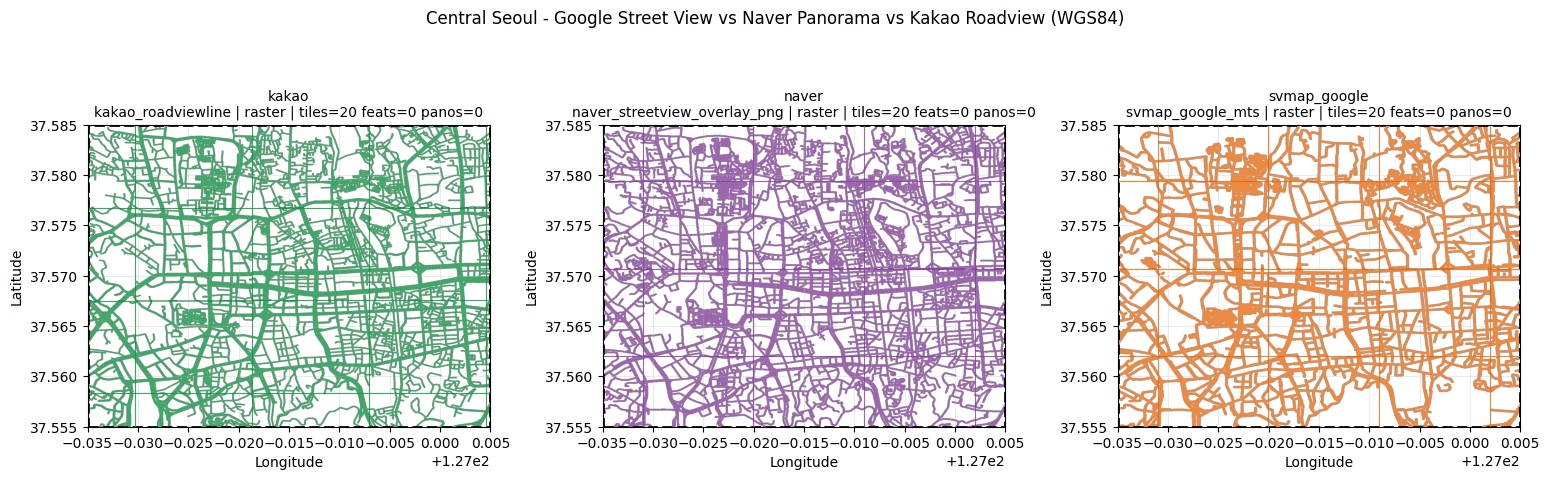

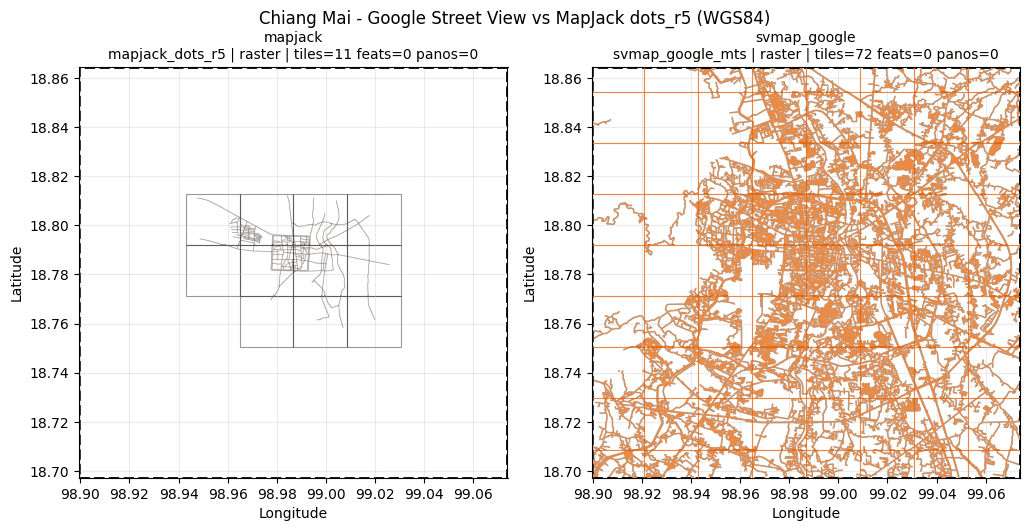

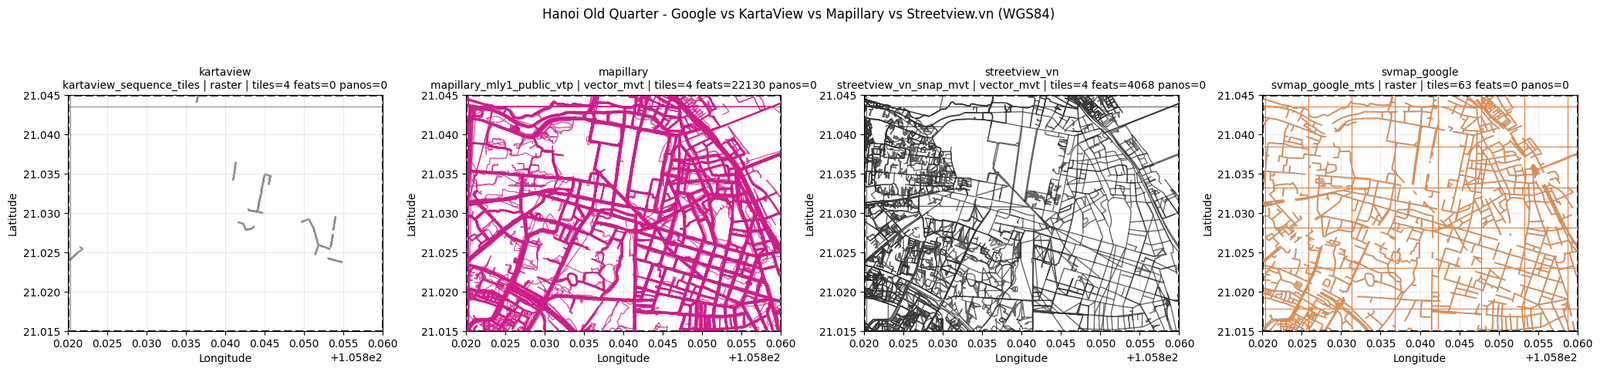

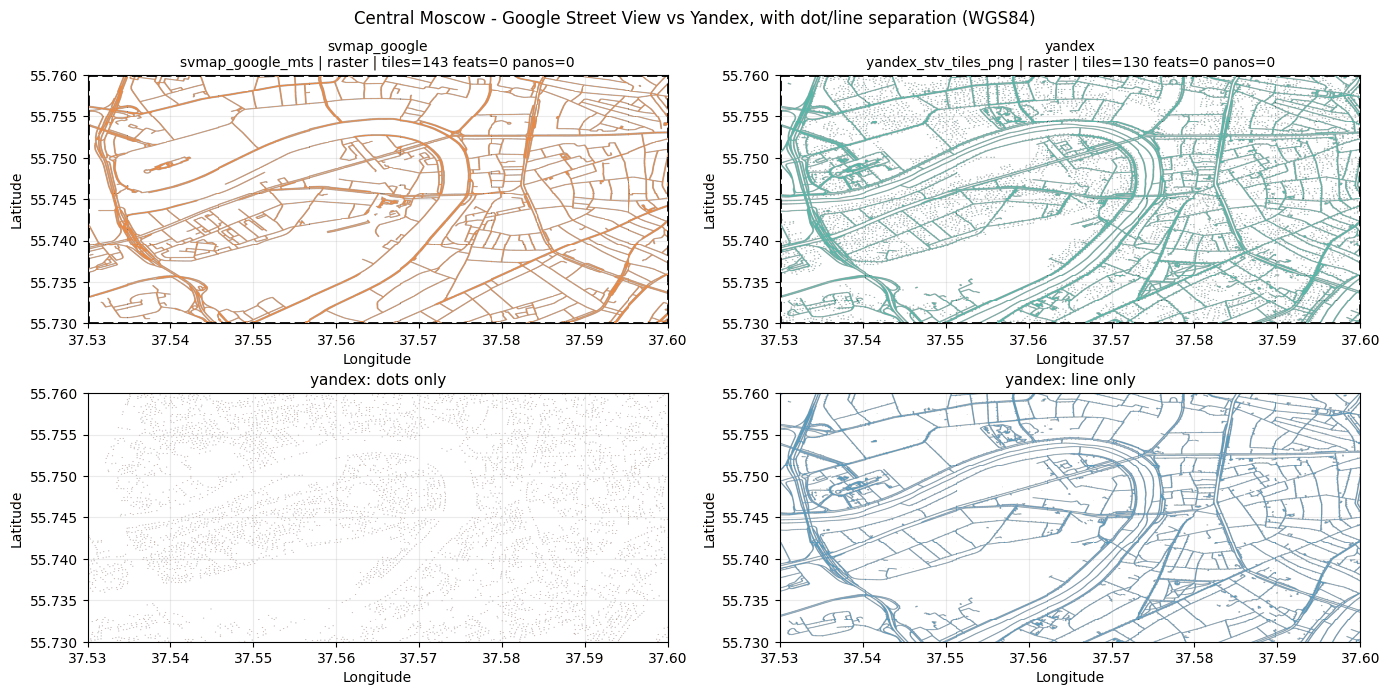

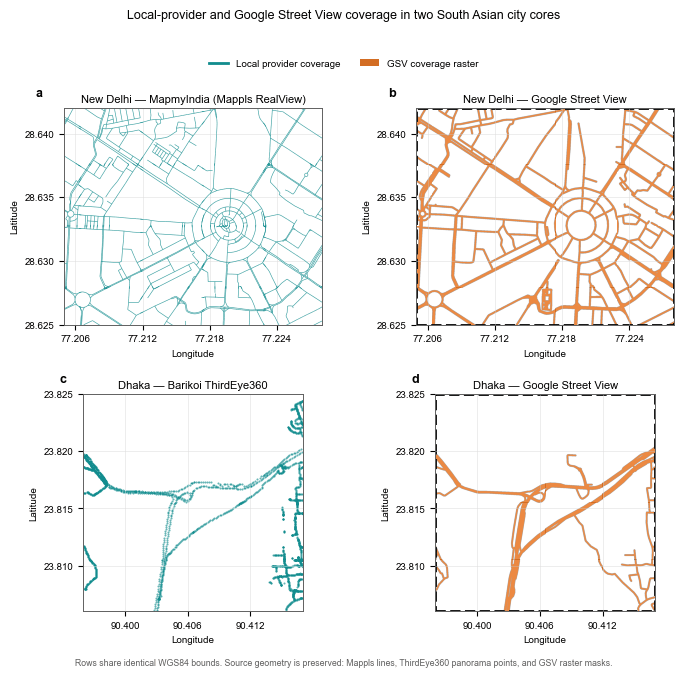

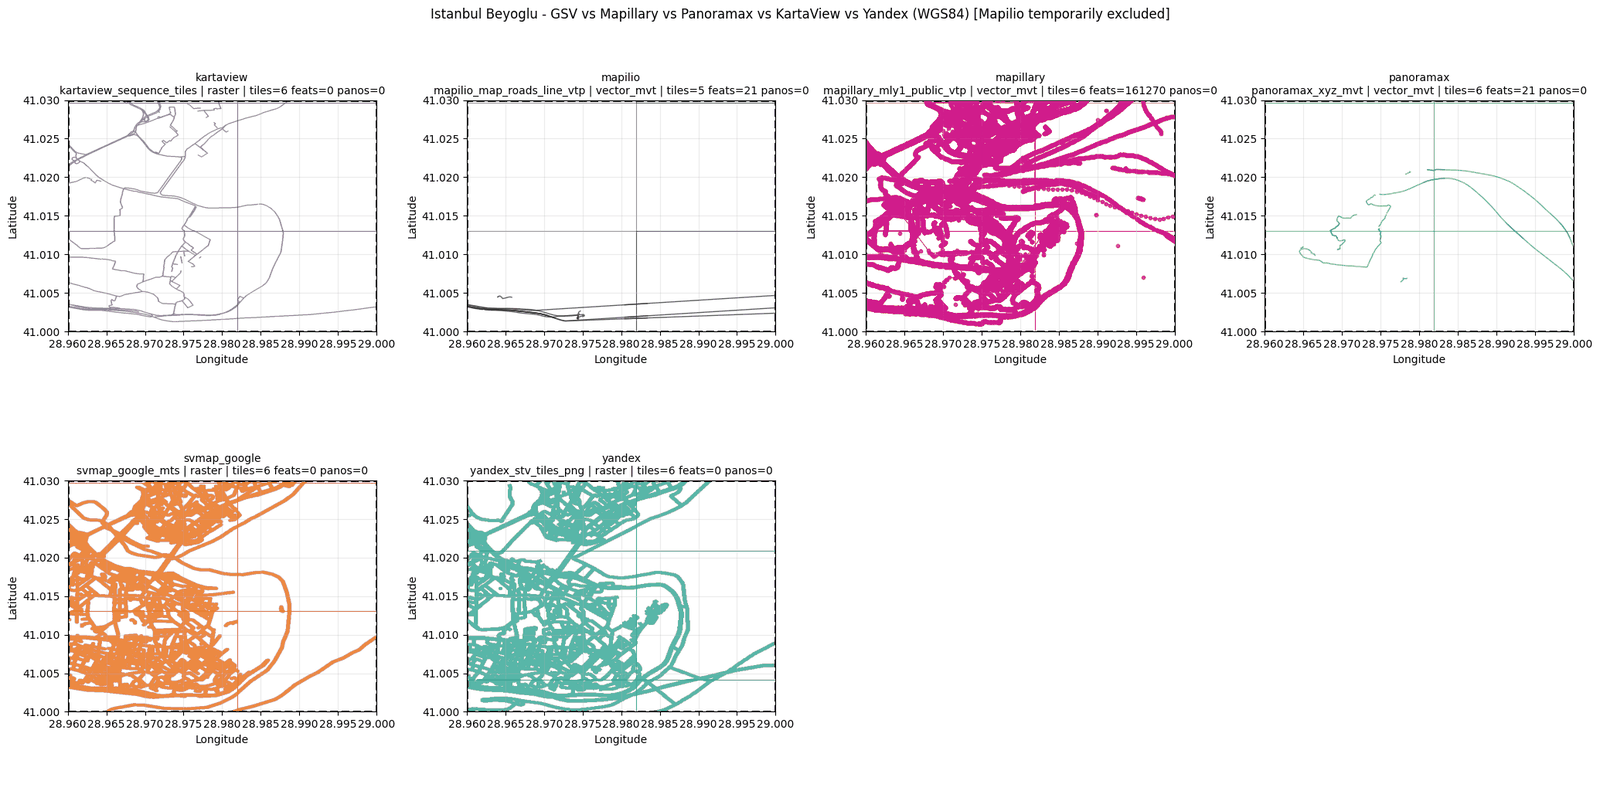

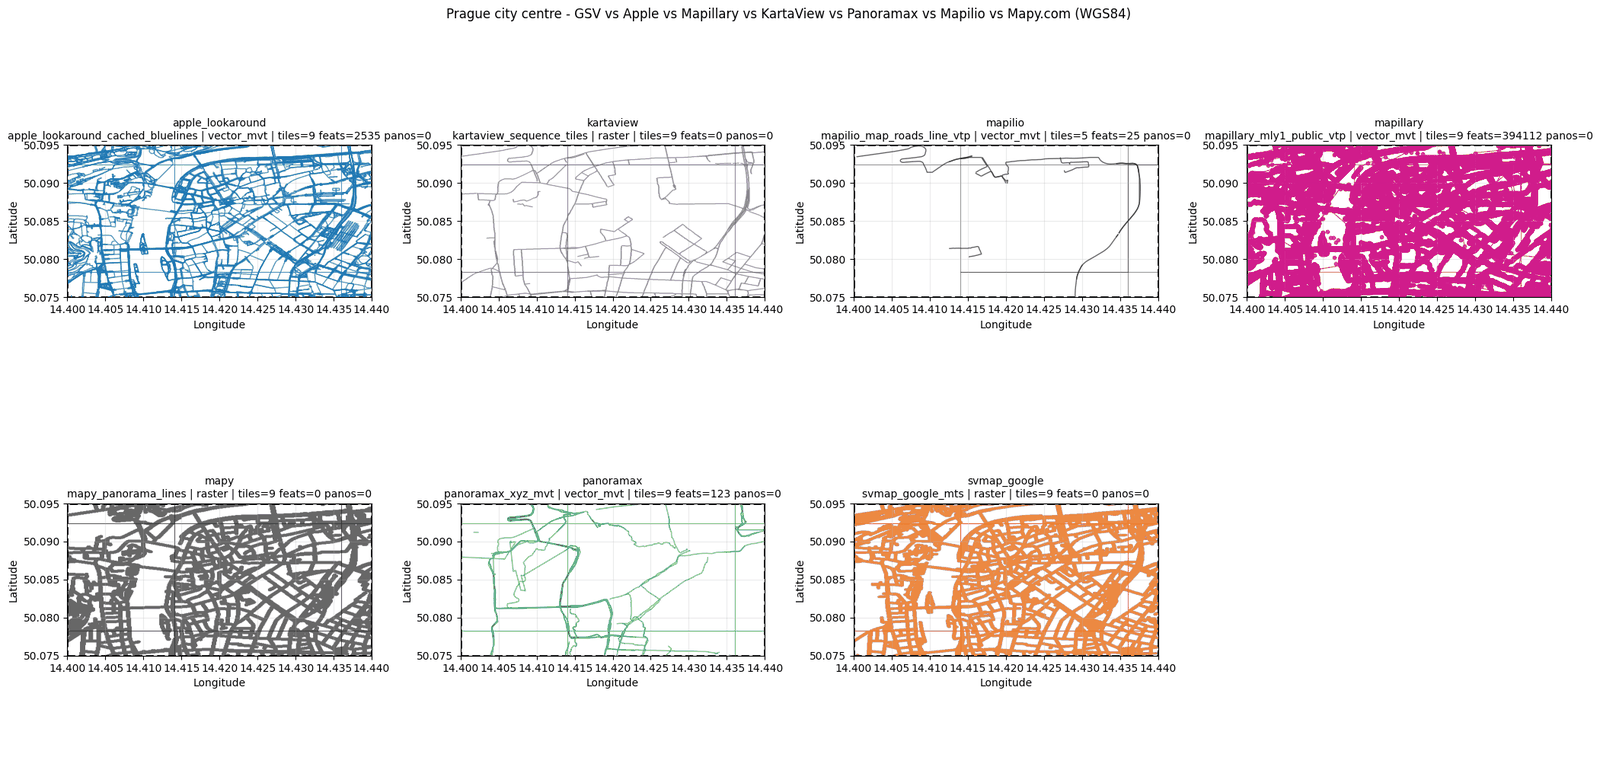

In [8]:
area_reference_paths = sorted(REFERENCE_FIGURE_ROOT.glob("area_*.png"))
if SHOW_REFERENCE_MAPS and area_reference_paths:
    for path in area_reference_paths:
        display(NotebookImage(filename=str(path)))
else:
    print(f"Embedded validated area-map plates: {len(area_reference_paths)} staged for this execution.")

## 2. Same-provider, multiscale comparison

Each provider keeps its existing case location and deterministic covered anchor. The audit distinguishes requested level from effective source level and never interprets an access or safety gate as absence of coverage.


In [9]:
zoom_plan_df = pd.DataFrame(multiscale_plan())
display(
    zoom_plan_df.groupby(["provider", "plan_status"], as_index=False).size().sort_values(["provider", "plan_status"])
)

barikoi_plan = zoom_plan_df.loc[
    zoom_plan_df["provider"].eq("barikoi"),
    ["requested_level", "effective_source_level", "source_id", "planned_tiles", "plan_status", "note"],
]
display(barikoi_plan)

,provider,plan_status,size
0,apple_lookaround,access_gated,13
1,baidu,planned,13
2,barikoi,planned,11
3,barikoi,unsupported,2
4,kakao,planned,13
5,kartaview,planned,13
6,mapilio,planned,13
7,mapillary,requires_token,13
8,mapjack,planned,6
9,mapjack,unsupported,7


,requested_level,effective_source_level,source_id,planned_tiles,plan_status,note
156,5,NaN,NaN,NaN,unsupported,Outside the declared source level range.
157,6,NaN,NaN,NaN,unsupported,Outside the declared source level range.
158,7,7.0,barikoi_thirdeye360_mvt,1.0,planned,
159,8,8.0,barikoi_thirdeye360_mvt,1.0,planned,
160,9,9.0,barikoi_thirdeye360_mvt,1.0,planned,
161,10,10.0,barikoi_thirdeye360_mvt,1.0,planned,
162,11,11.0,barikoi_thirdeye360_mvt,1.0,planned,
163,12,12.0,barikoi_thirdeye360_mvt,1.0,planned,
164,13,13.0,barikoi_thirdeye360_mvt,1.0,planned,
165,14,14.0,barikoi_thirdeye360_mvt,1.0,planned,


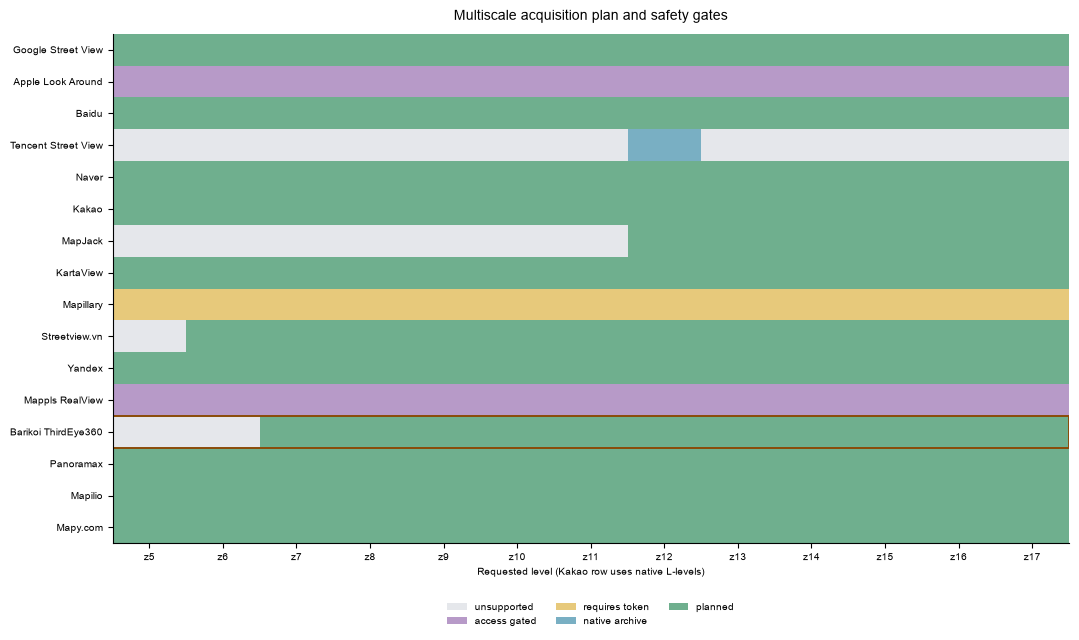

In [10]:
status_order = ["unsupported", "access_gated", "requires_token", "native_archive", "planned"]
status_colors = ["#E5E7EB", "#B79AC8", "#E7C97B", "#79AFC3", "#6FAF8E"]
status_index = {status: index for index, status in enumerate(status_order)}
provider_order = [case.provider for case in MULTISCALE_CASES]
matrix = np.zeros((len(provider_order), len(MULTISCALE_LEVELS)), dtype=int)
for row_index, provider_key in enumerate(provider_order):
    provider_rows = zoom_plan_df.loc[zoom_plan_df["provider"].eq(provider_key)].set_index("requested_level")
    for column_index, level in enumerate(MULTISCALE_LEVELS):
        matrix[row_index, column_index] = status_index[provider_rows.loc[level, "plan_status"]]

cmap = ListedColormap(status_colors)
norm = BoundaryNorm(np.arange(-0.5, len(status_order) + 0.5), cmap.N)
fig, ax = plt.subplots(figsize=(10.8, 6.4))
ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(MULTISCALE_LEVELS)), [f"z{level}" for level in MULTISCALE_LEVELS])
ax.set_yticks(range(len(provider_order)), [PROVIDER_LABELS[key] for key in provider_order])
ax.set_xlabel("Requested level (Kakao row uses native L-levels)")
ax.set_title("Multiscale acquisition plan and safety gates", fontsize=10, pad=10)
barikoi_index = provider_order.index("barikoi")
ax.add_patch(
    Rectangle((-0.5, barikoi_index - 0.5), len(MULTISCALE_LEVELS), 1, fill=False, edgecolor="#8A4B08", linewidth=1.4)
)
ax.legend(
    handles=[
        Patch(facecolor=color, label=status.replace("_", " ")) for status, color in zip(status_order, status_colors)
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
)
fig.tight_layout()
plt.show()

### Barikoi correction and ephemeral rendering

The earlier multiscale failure came from notebook-local registration: the comparison cell registered Barikoi, but the later audit could run without that state and returned `Provider registration missing`. Barikoi is now a permanent shared registry provider, and every provider-declared level from z7 through z17 is permitted. Because low-level ThirdEye360 tiles may be large, the reference build processes one tile at a time and deletes its raw run directory immediately after drawing the panel.


In [11]:
assert validate_multiscale_probe("barikoi", 7)["source_id"] == "barikoi_thirdeye360_mvt"
assert validate_multiscale_probe("barikoi", 17)["source_id"] == "barikoi_thirdeye360_mvt"


async def acquire_multiscale_probe(provider_key: str, requested_level: int):
    plan = validate_multiscale_probe(provider_key, requested_level)
    if not ALLOW_NETWORK:
        raise RuntimeError("Set ALLOW_NETWORK=True before running a multiscale probe.")
    if provider_key in {"apple_lookaround", MAPPLS_KEY} and provider_key not in AUTHORIZED_ACCESS_GATED:
        raise PermissionError(f"Add {provider_key!r} to AUTHORIZED_ACCESS_GATED after authorization review.")
    case = multiscale_case(provider_key)
    bbox = multiscale_probe_bbox(case)
    run_label = f"multiscale_{provider_key}_l{requested_level}"
    if provider_key in PROVIDERS:
        if provider_key == "mapillary" and not MAPILLARY_ACCESS_TOKEN:
            raise RuntimeError("Set MAPILLARY_ACCESS_TOKEN in the environment.")
        return fetch_provider_coverage(
            FetchAreaRequest(
                provider=provider_key,
                bbox=bbox,
                output_root=OUTPUT_ROOT,
                display_zoom=requested_level,
                stop_on_error=False,
                timeout_seconds=180 if provider_key == "barikoi" else 30,
                run_label=run_label,
                access_token=MAPILLARY_ACCESS_TOKEN if provider_key == "mapillary" else None,
            )
        )
    if provider_key == TENCENT_KEY:
        return fetch_tencent_pmtiles_sv_coverage(
            bbox,
            output_root=OUTPUT_ROOT,
            cache_dir=OUTPUT_ROOT / "tencent_pmtiles_cache",
            source_url=TENCENT_PMTILES_URL,
            source_zoom=int(plan["effective_source_level"]),
            run_label=f"{run_label}_subbox_00",
        )
    sdk_bbox = MapplsBBox(bbox.min_lon, bbox.min_lat, bbox.max_lon, bbox.max_lat)
    return await capture_sdk_bbox_async(
        web_dir=PROJECT_ROOT / "integrations" / "mappls_realview" / "web",
        bbox=sdk_bbox,
        zoom=requested_level,
        out_dir=OUTPUT_ROOT / "mappls_realview",
        output_mode="production",
        run_id=f"{run_label}_mappls",
        headless=True,
    )


live_multiscale_results = {}
for provider_key, requested_level in sorted(RUN_MULTISCALE_PROBES):
    live_multiscale_results[(provider_key, requested_level)] = await acquire_multiscale_probe(
        provider_key, requested_level
    )
print(f"Live multiscale probes executed: {len(live_multiscale_results)}")

Live multiscale probes executed: 0


### Validated multiscale map outputs

These plates show the actual returned coverage artifact at each requested level. Status-only panels identify unsupported, empty, gated or failed requests rather than treating them as evidence of absent coverage.


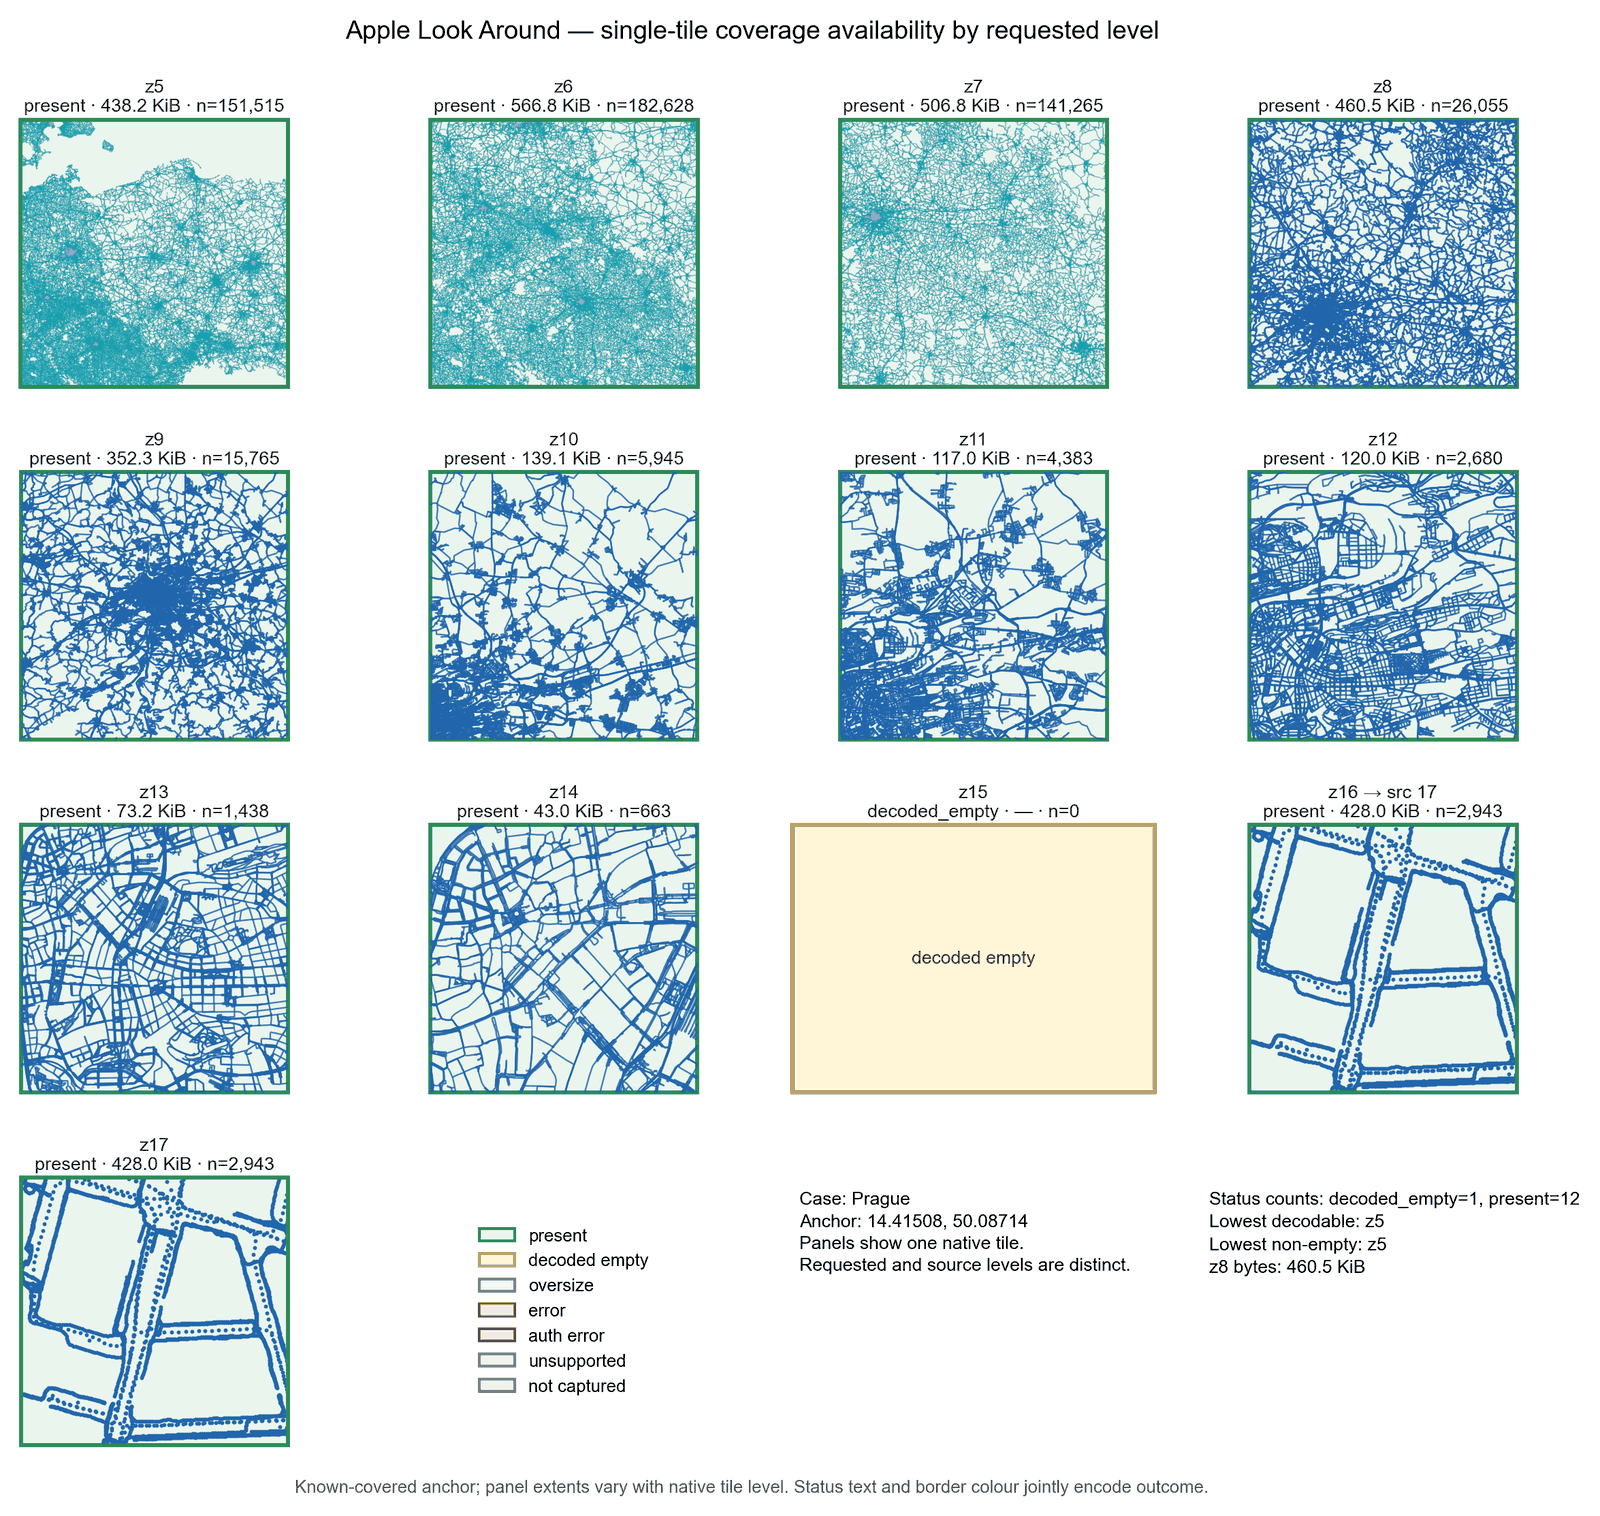

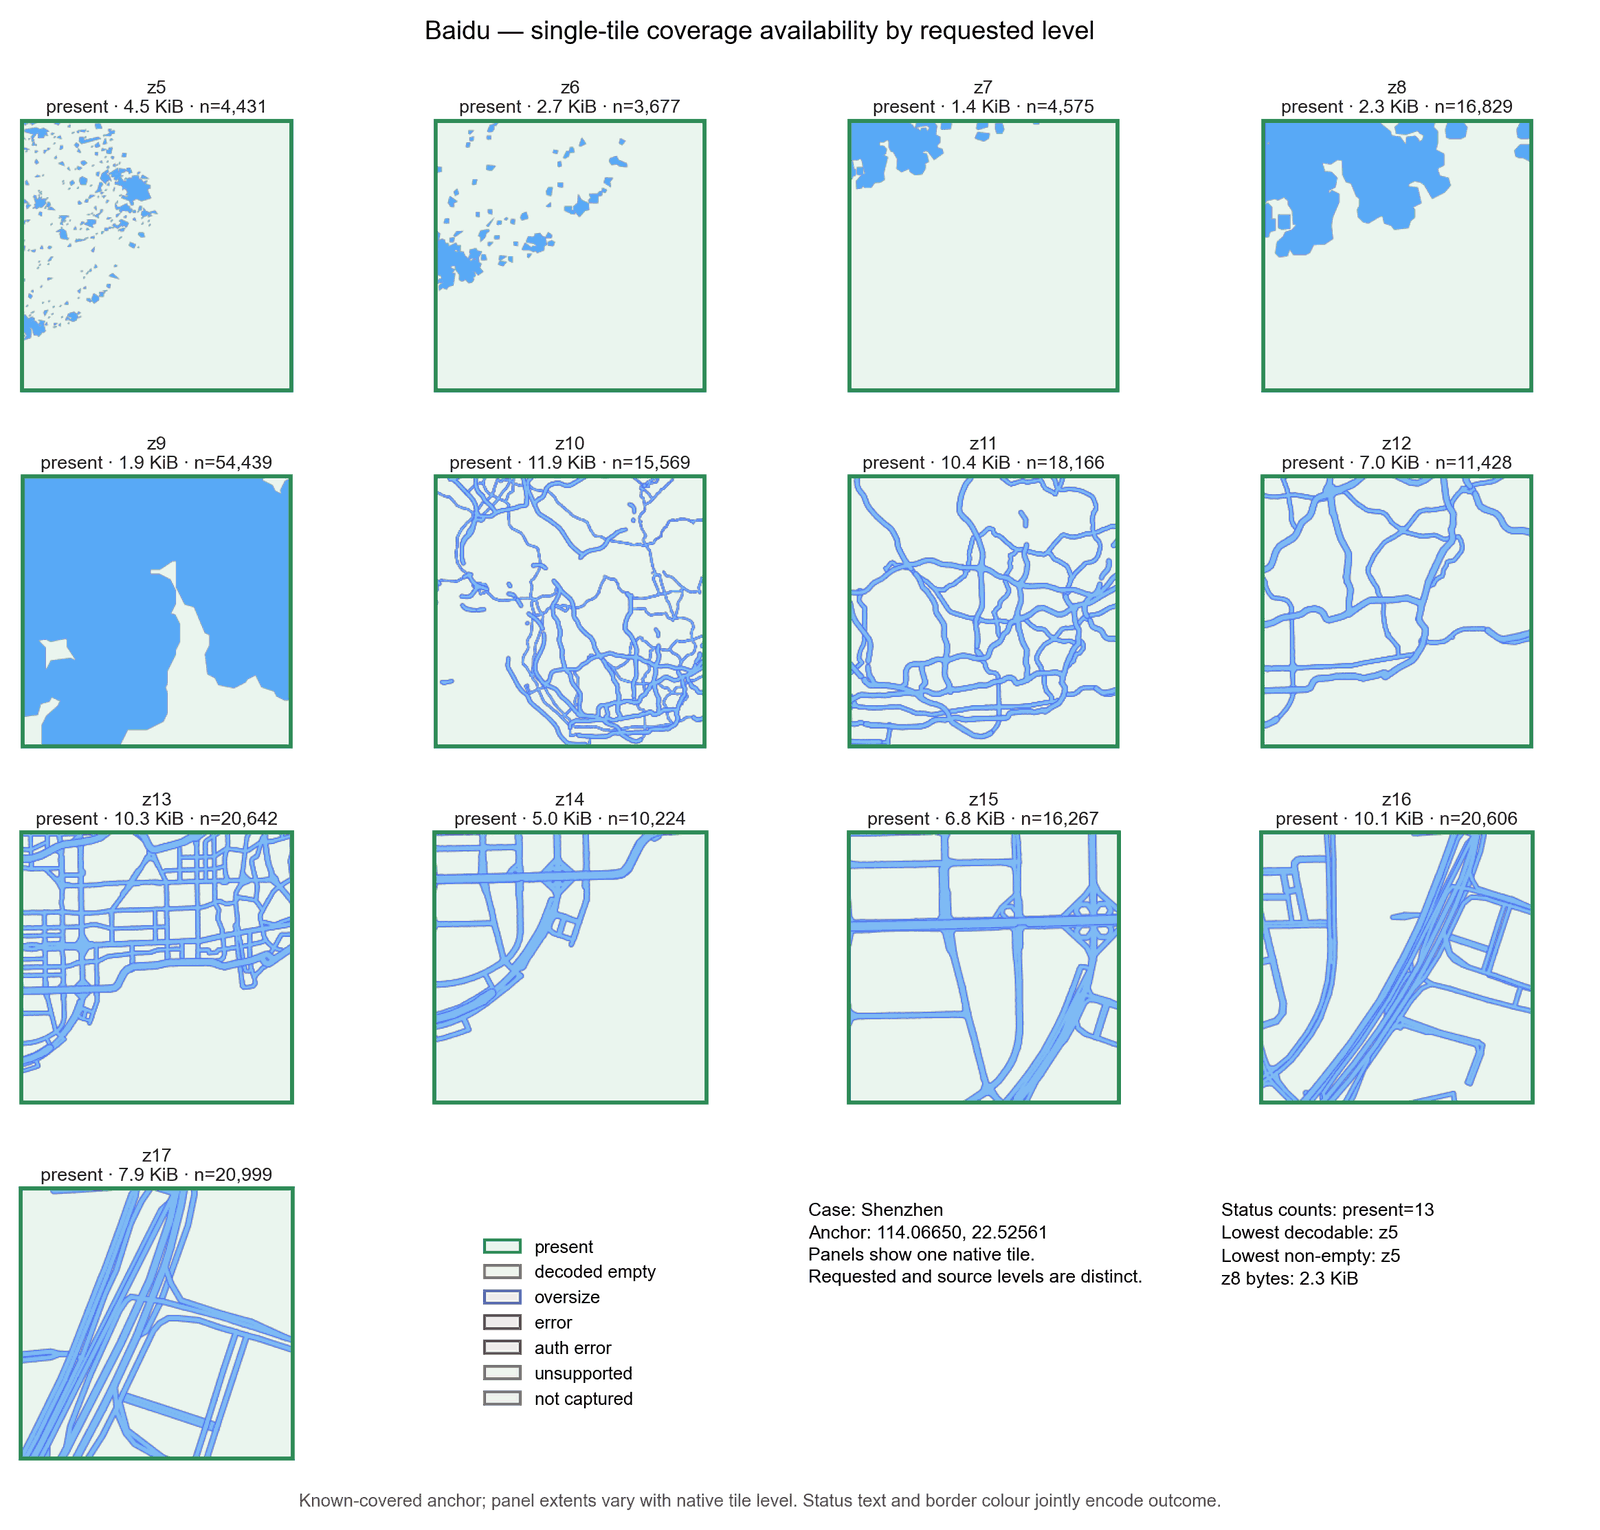

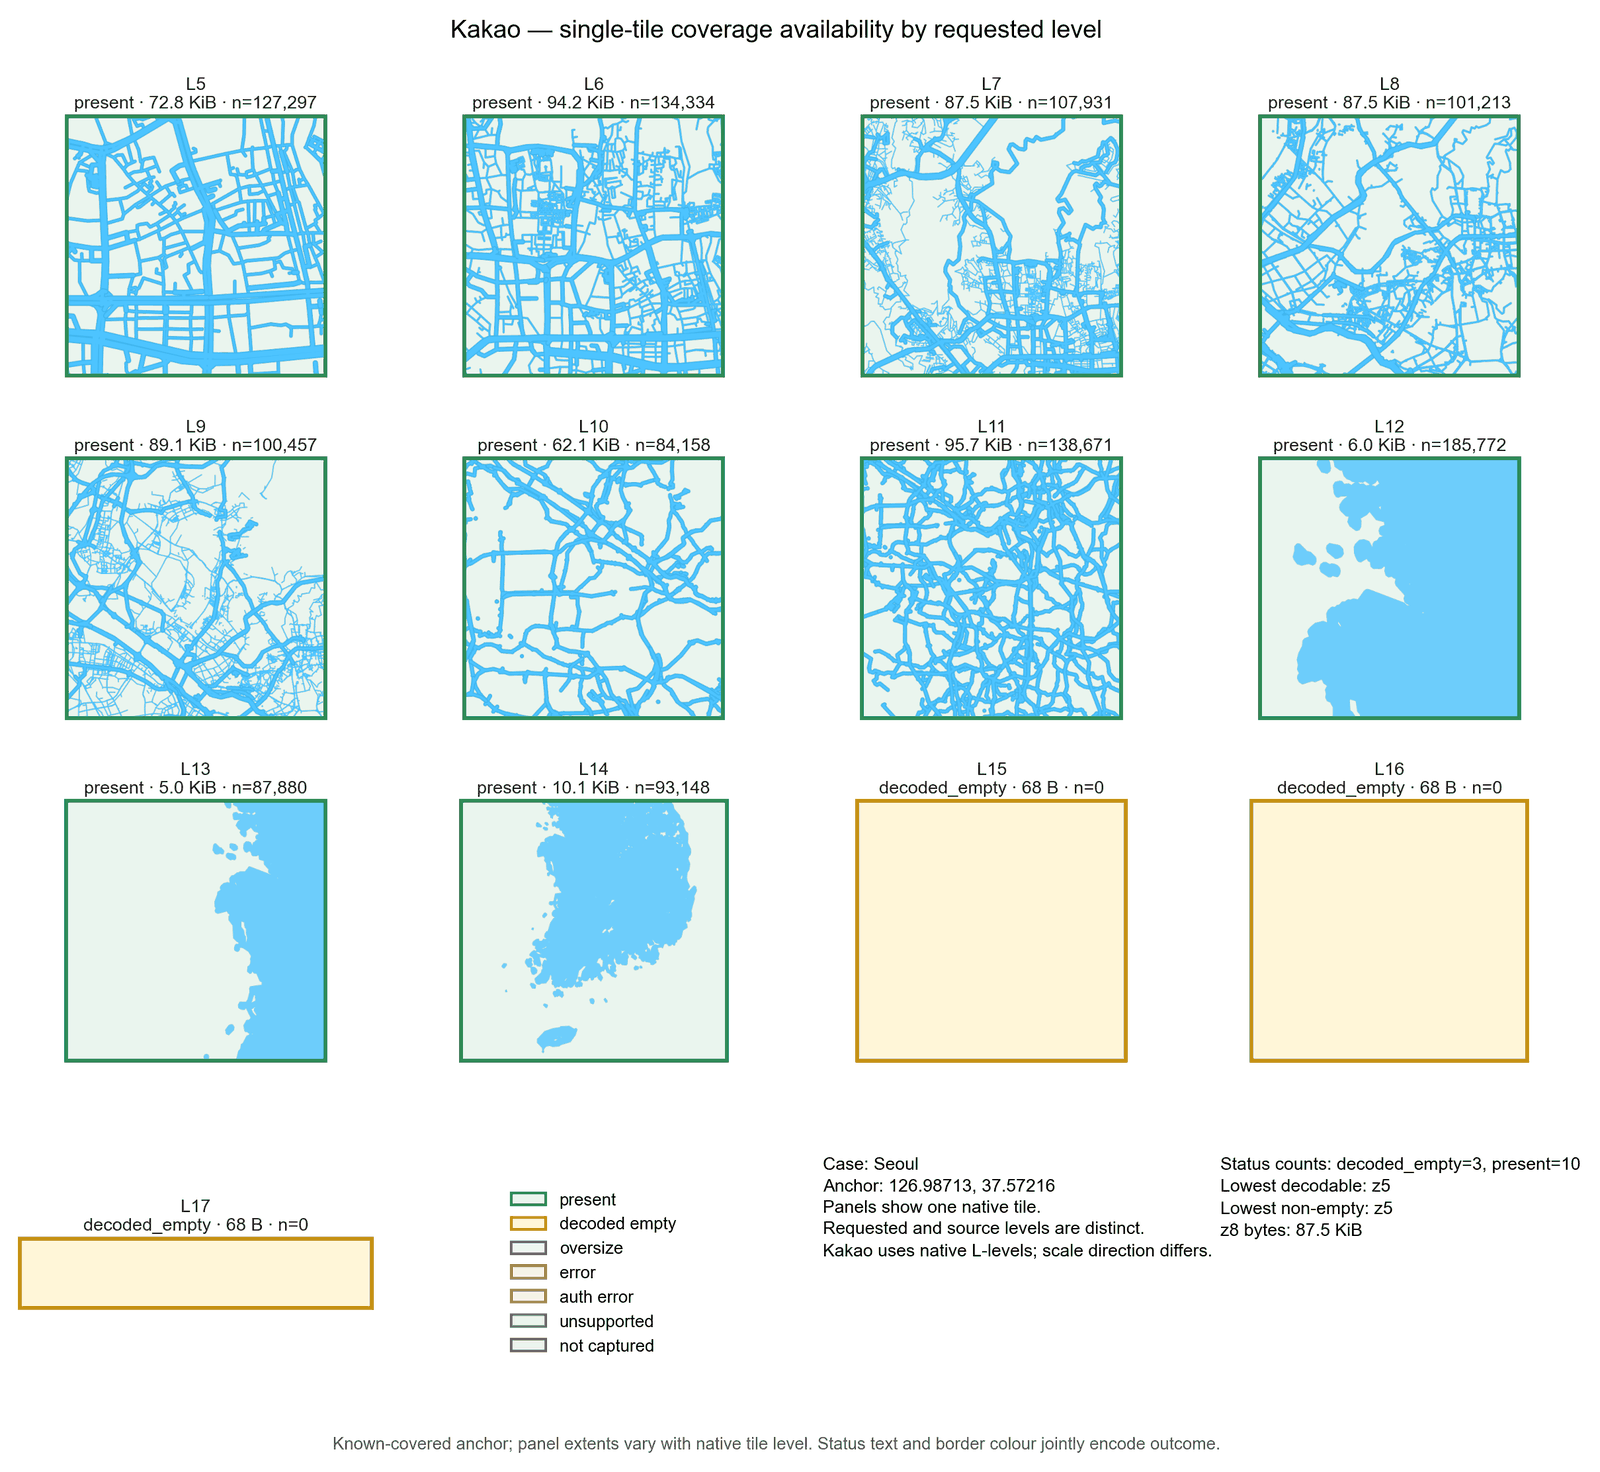

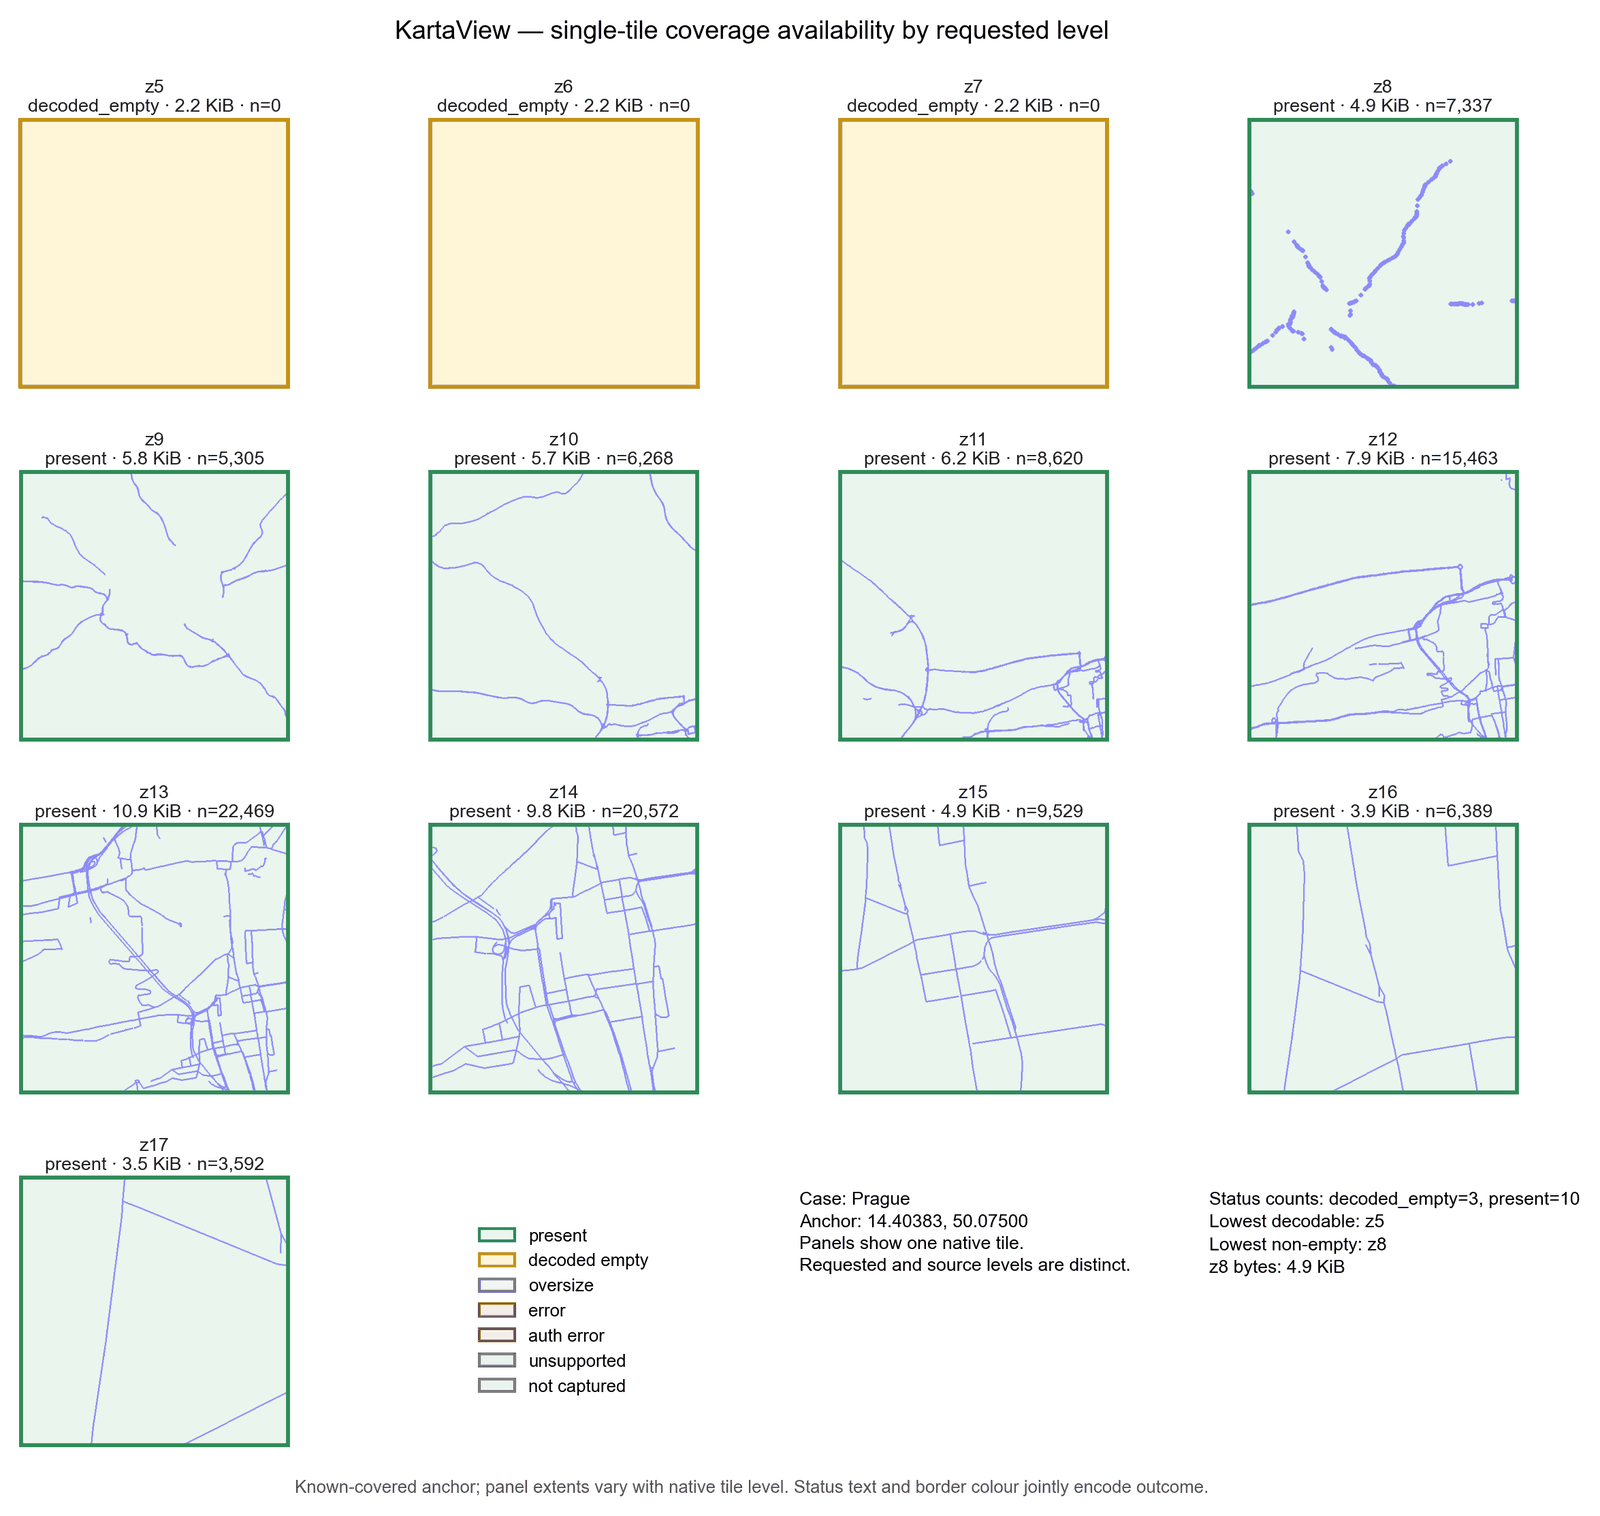

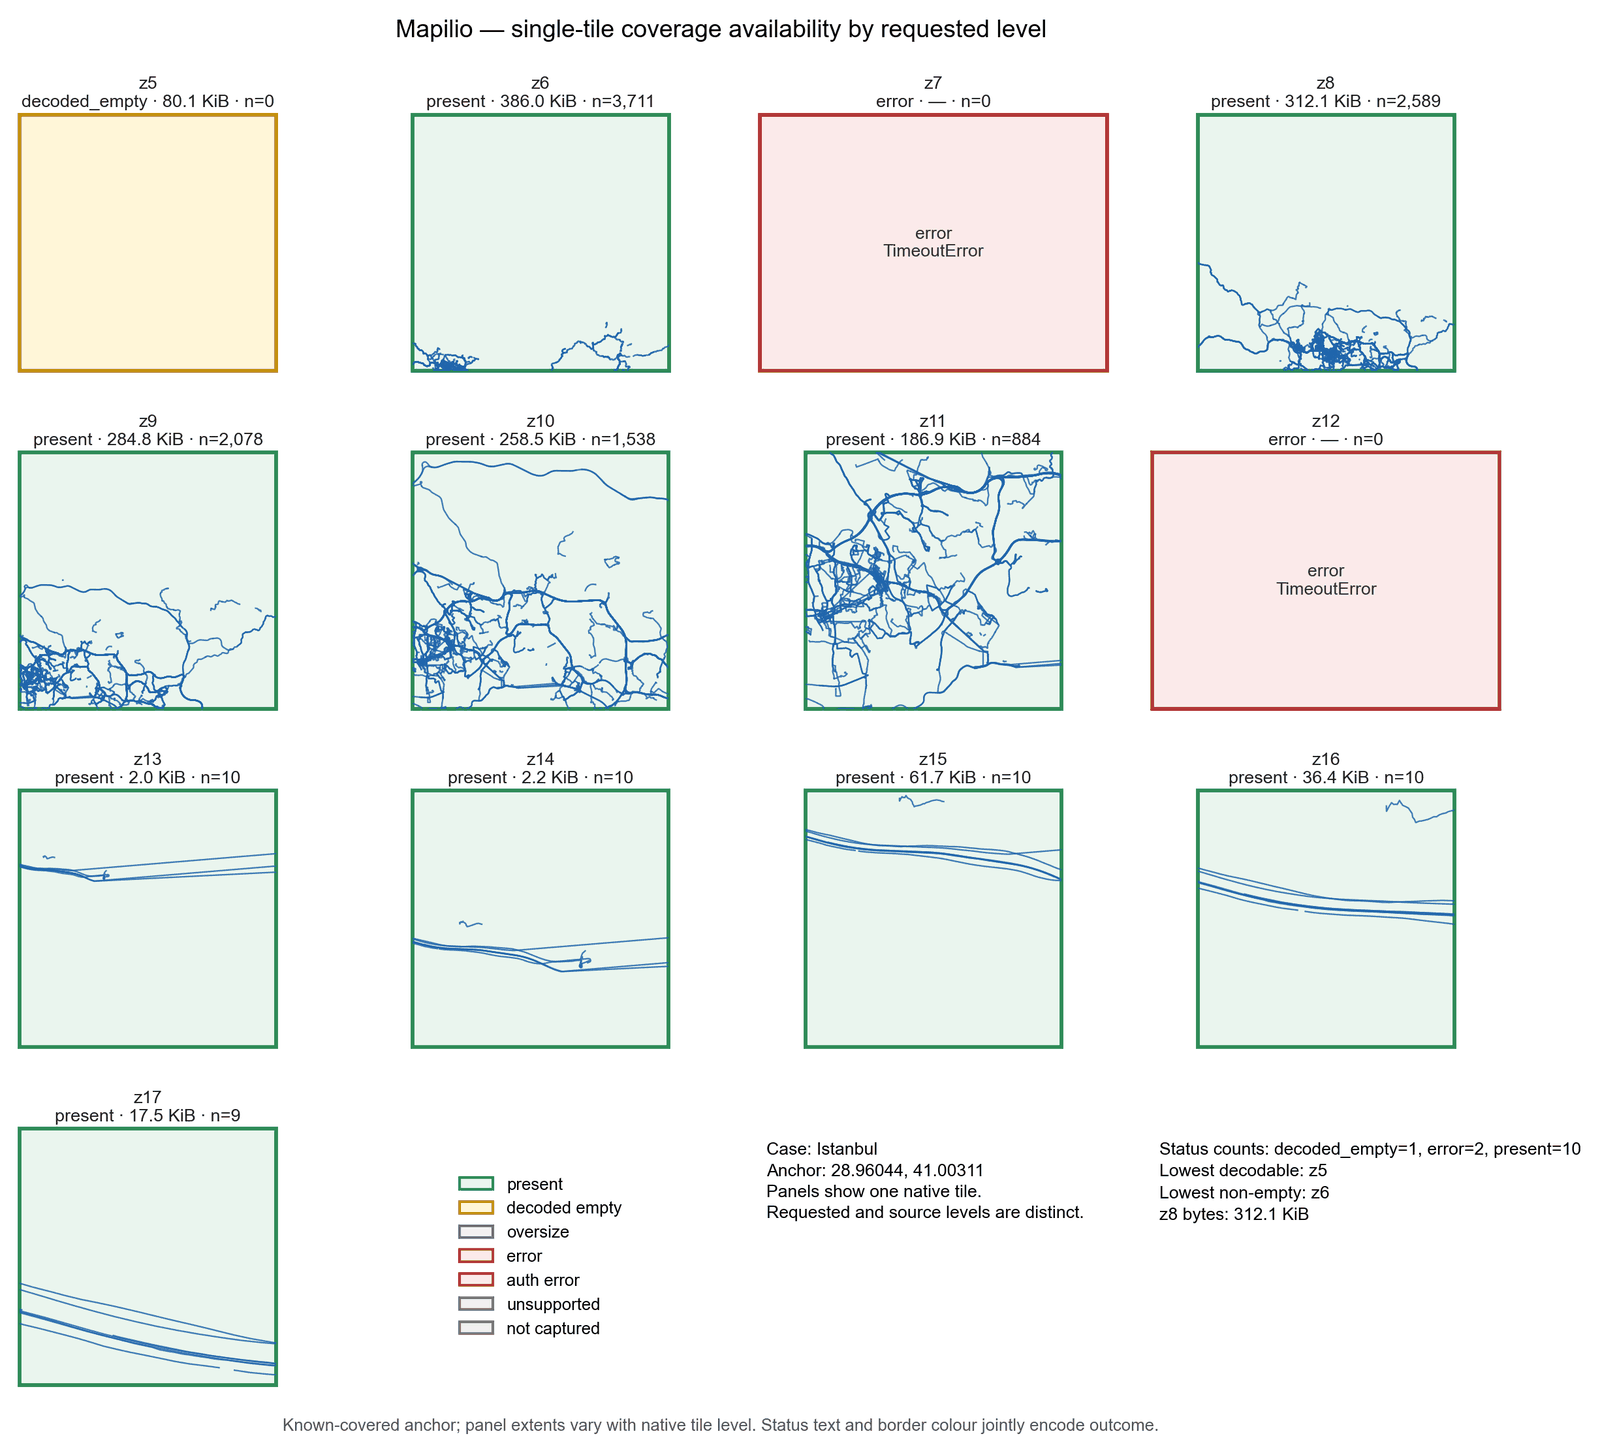

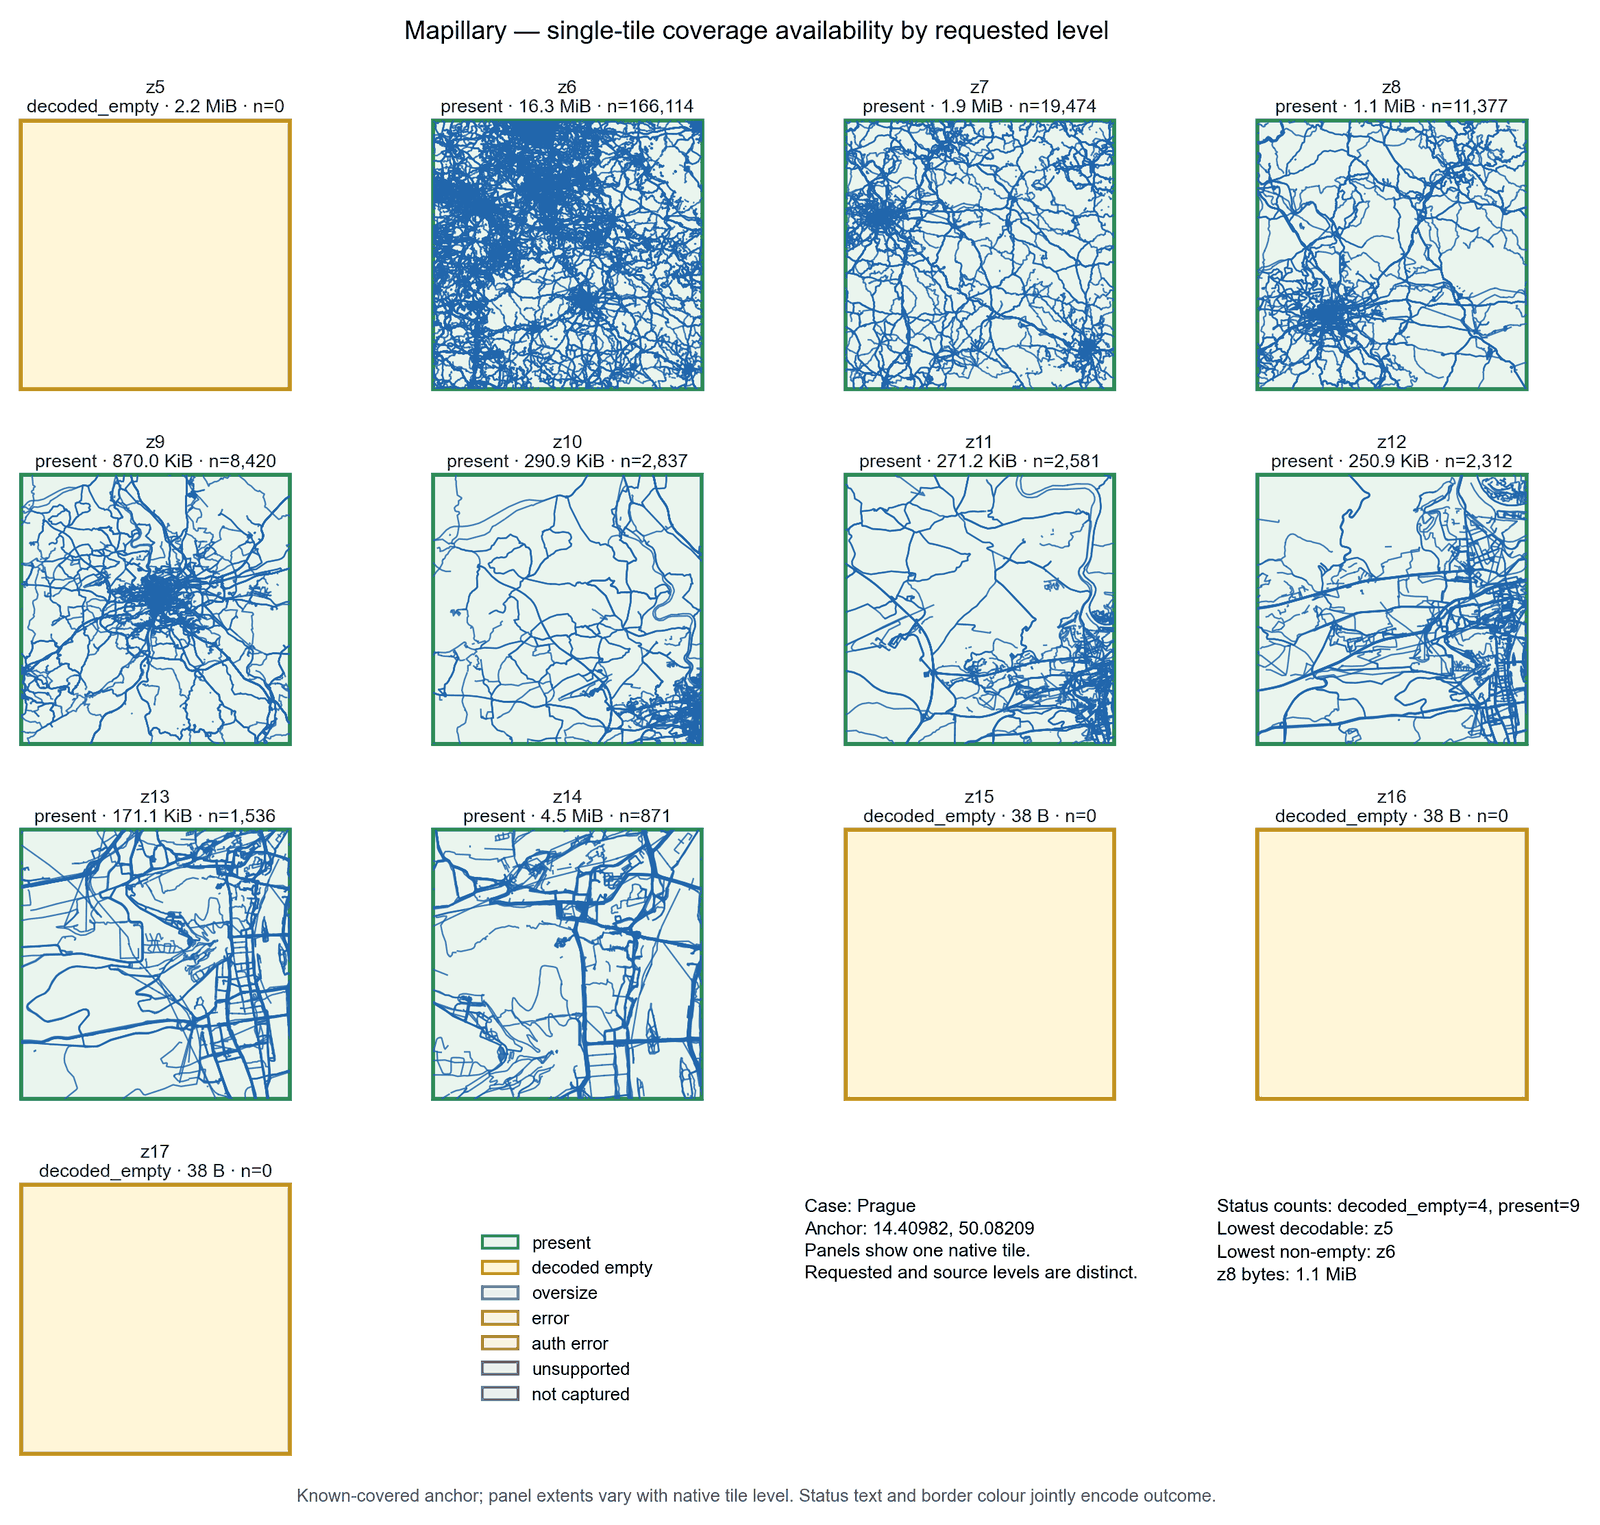

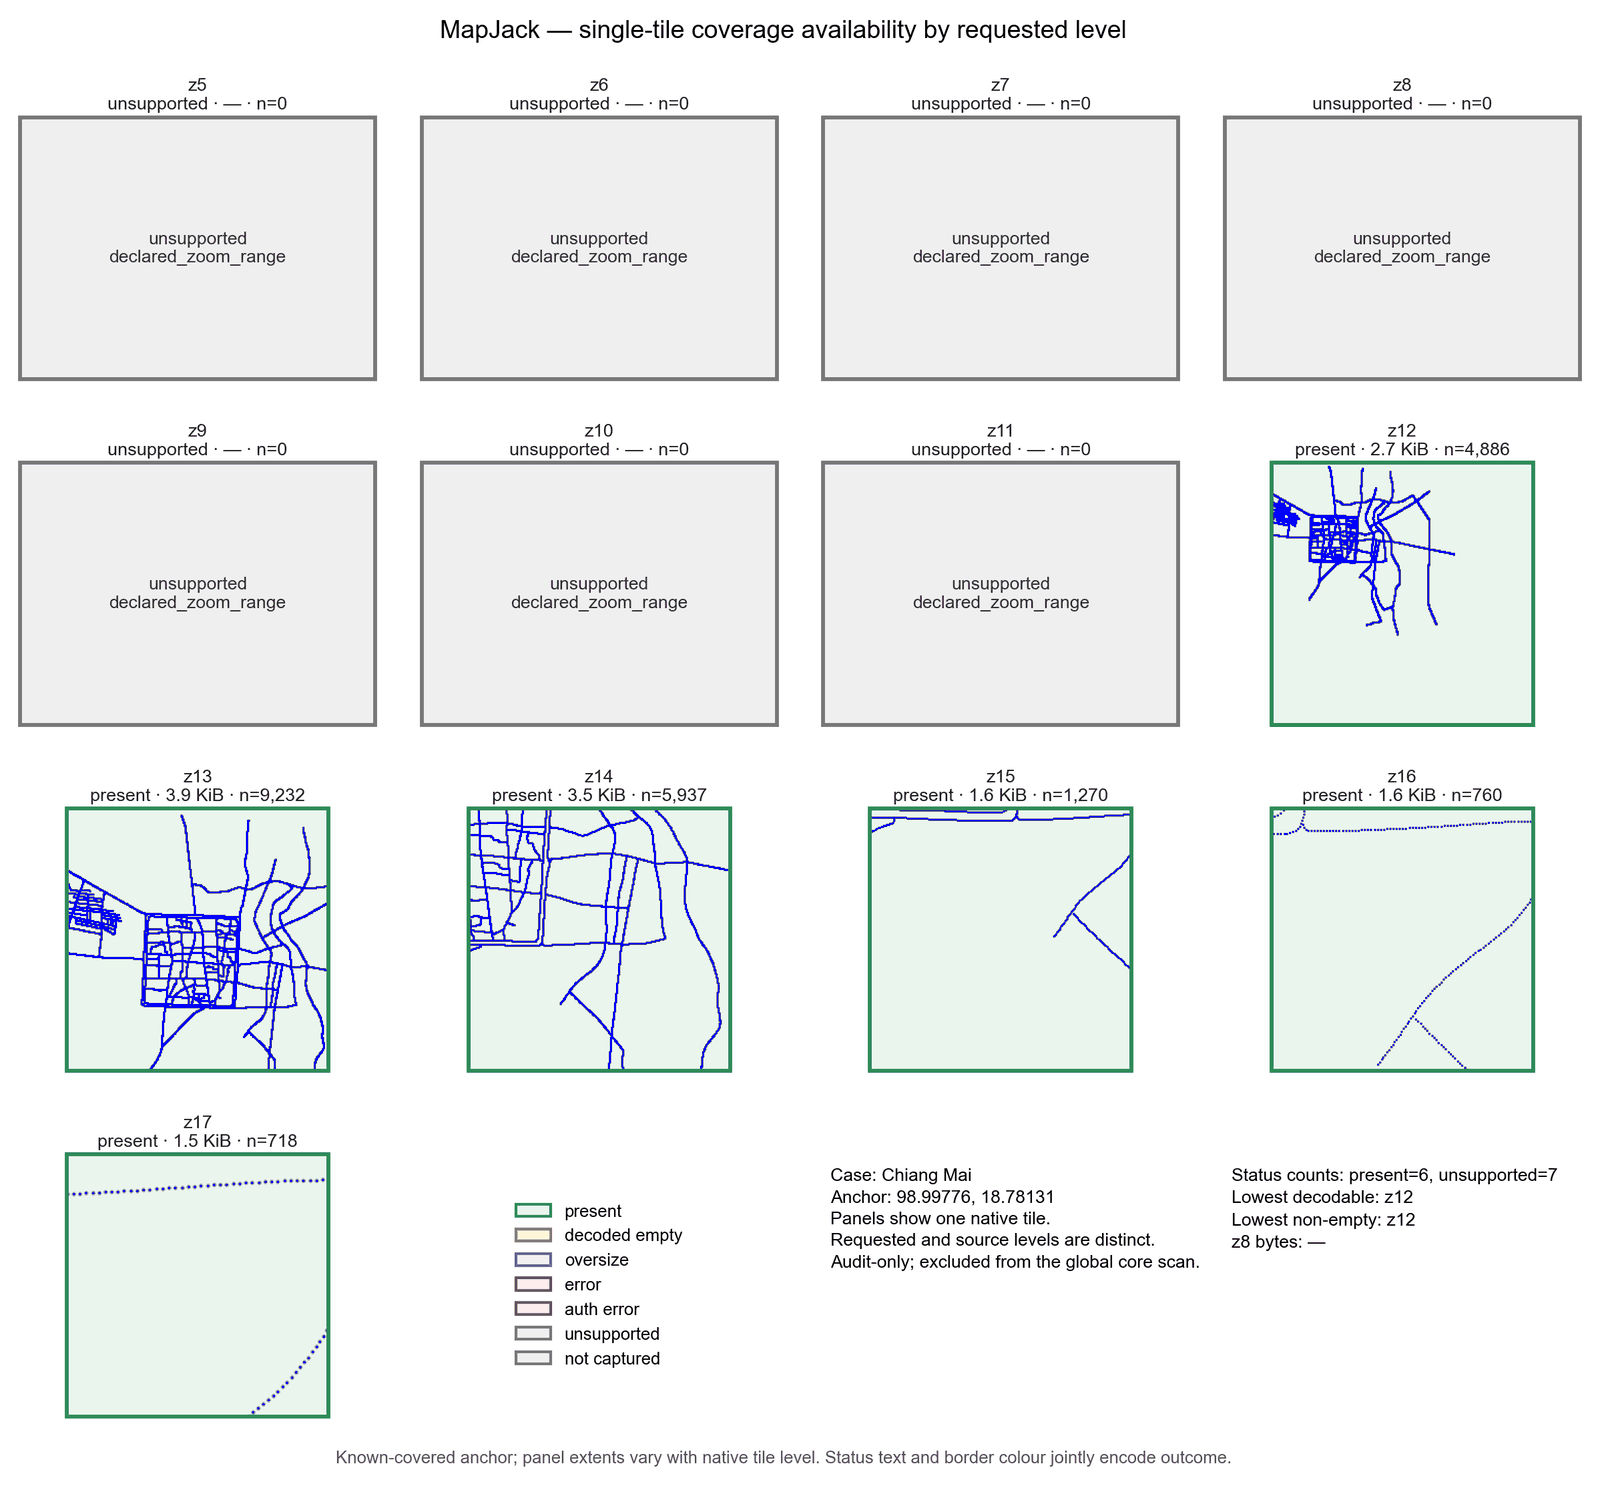

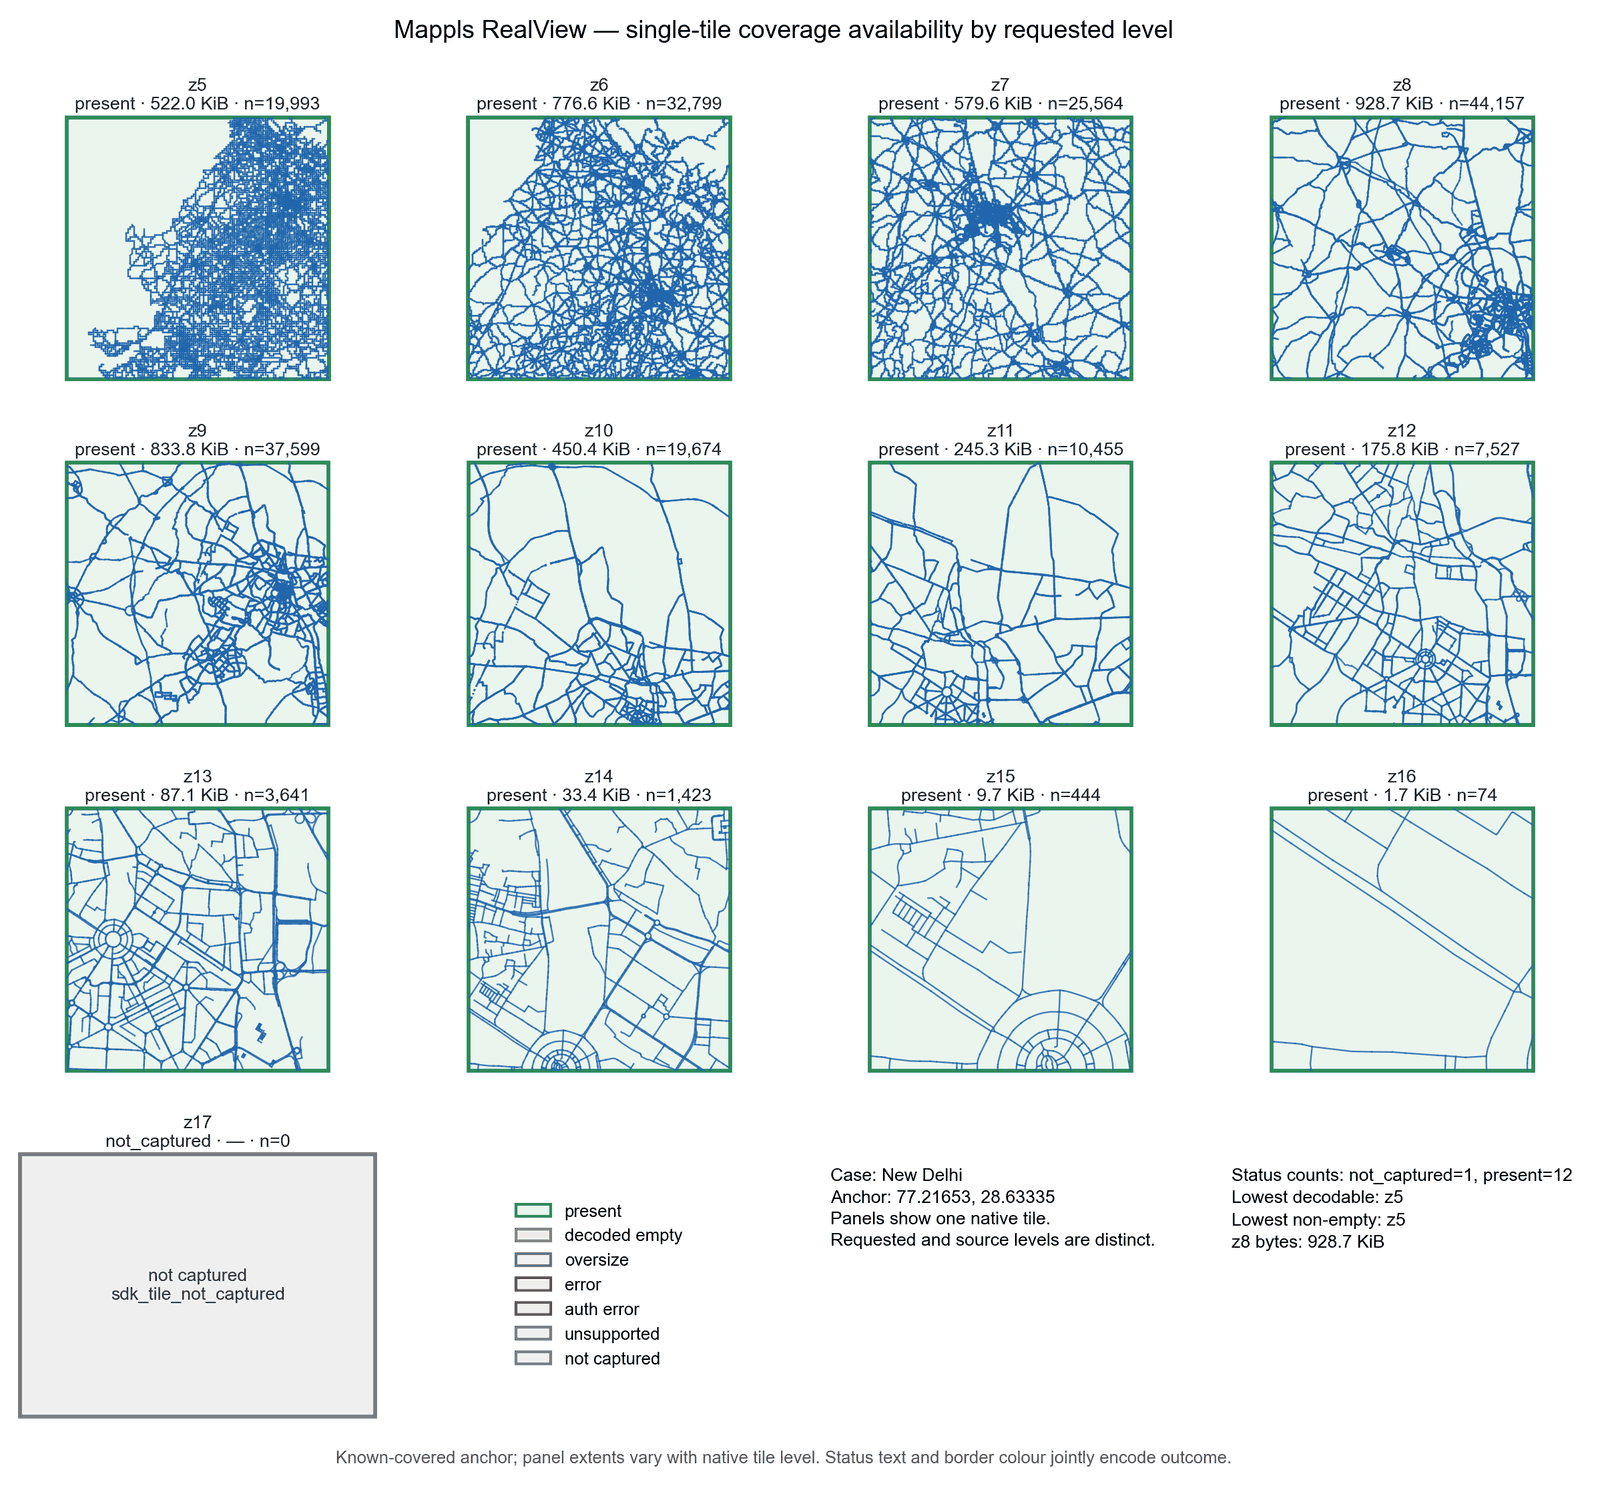

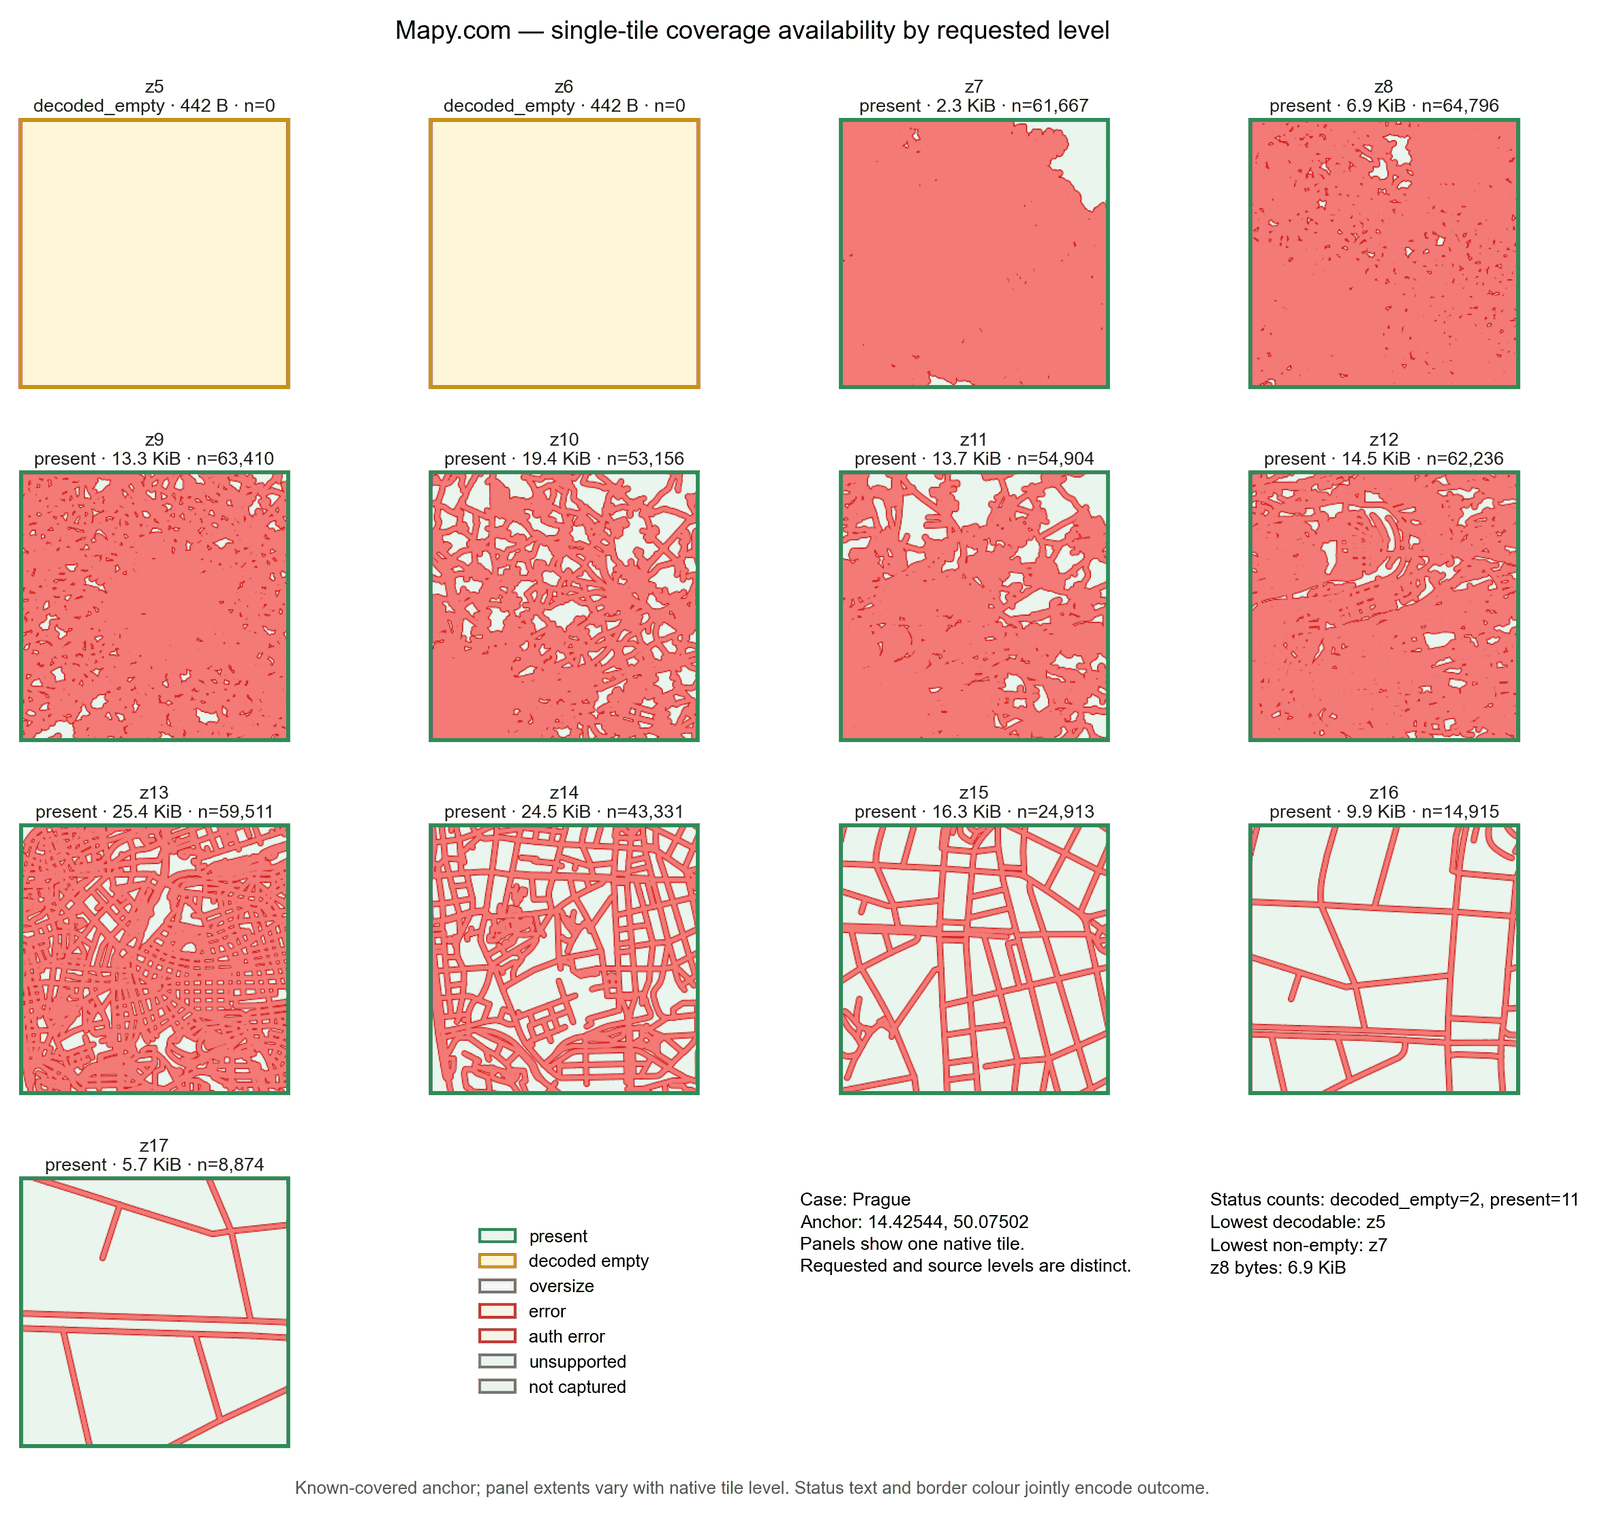

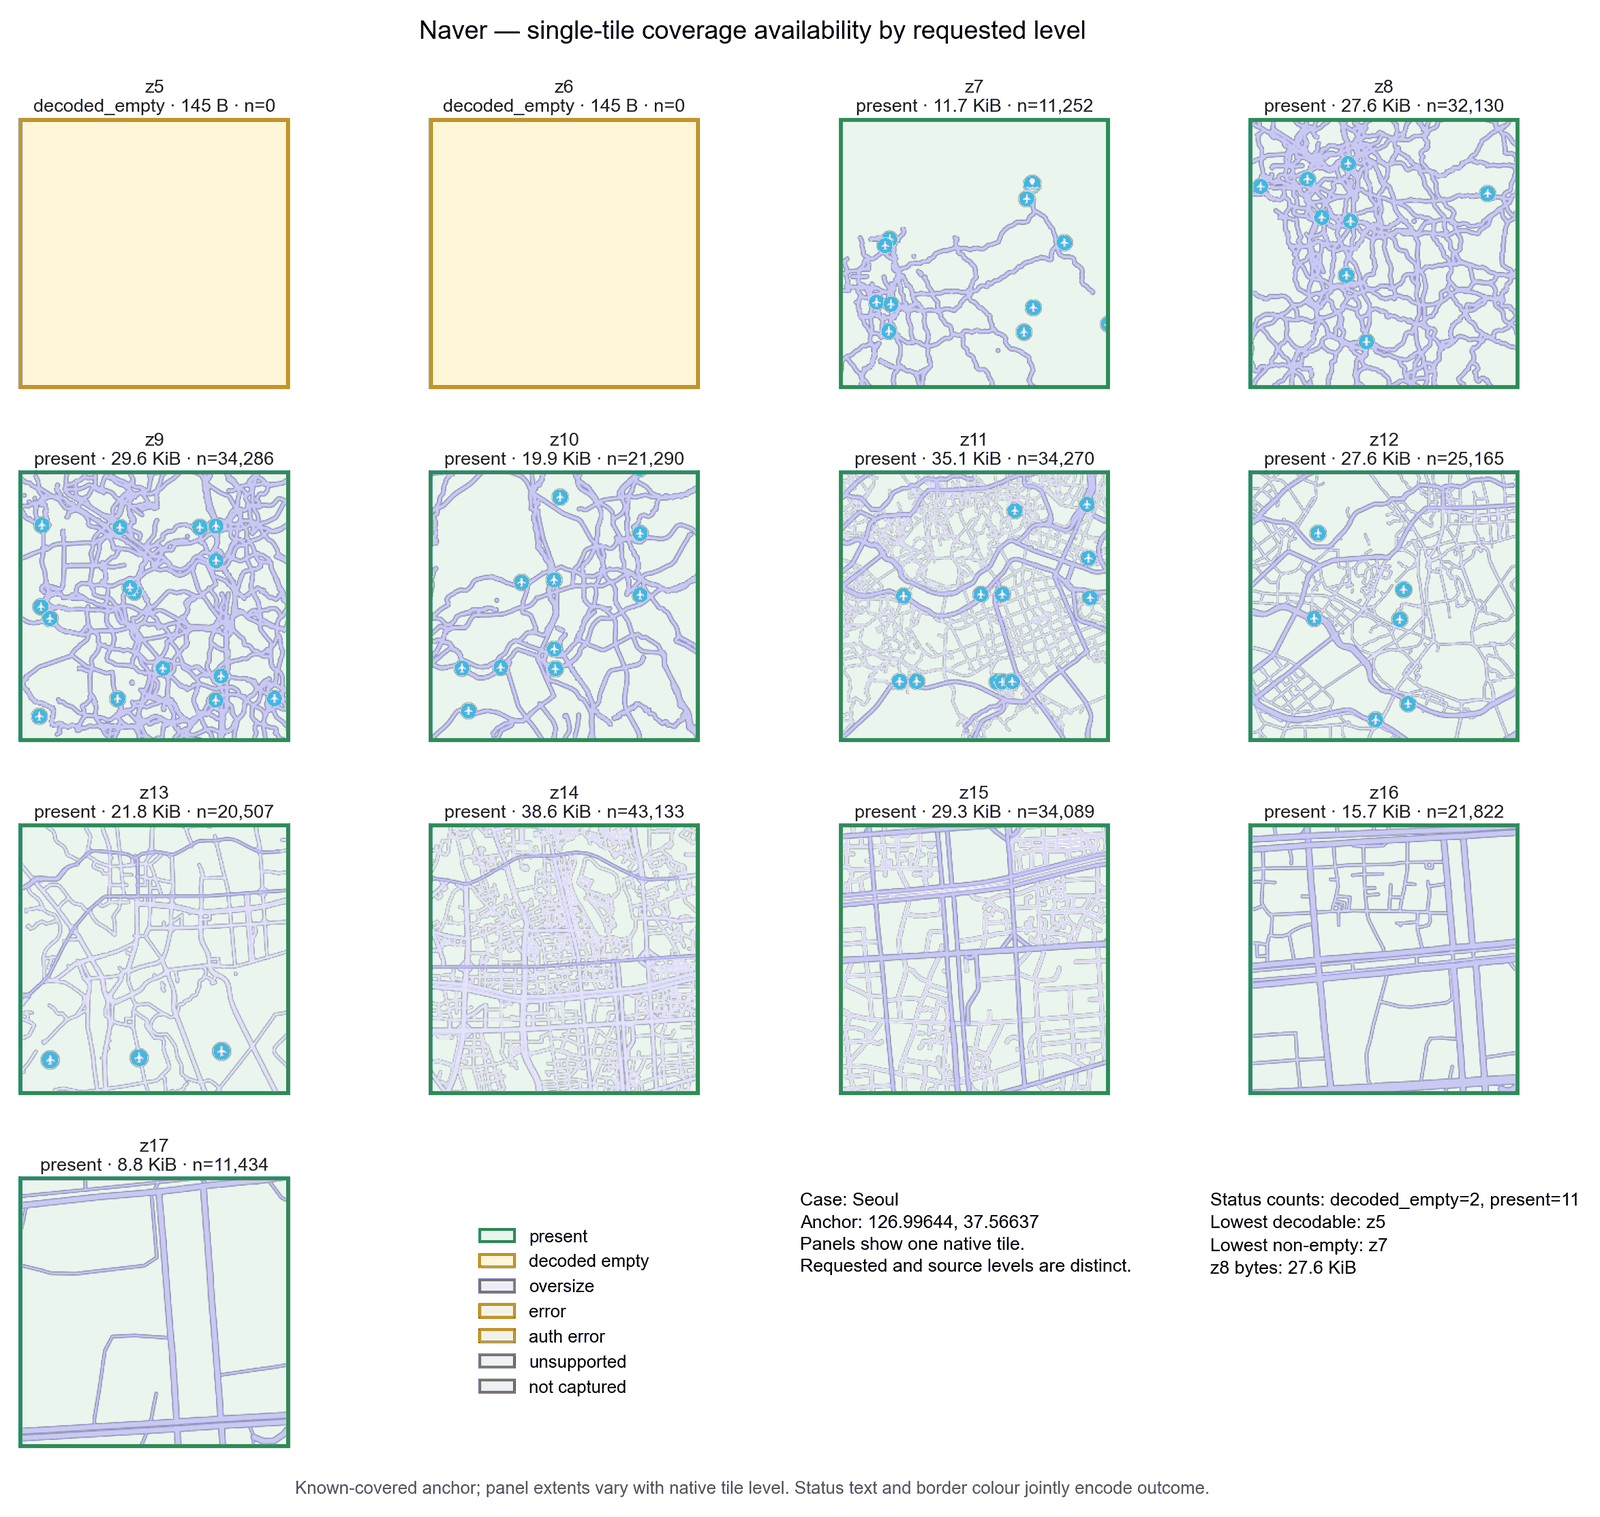

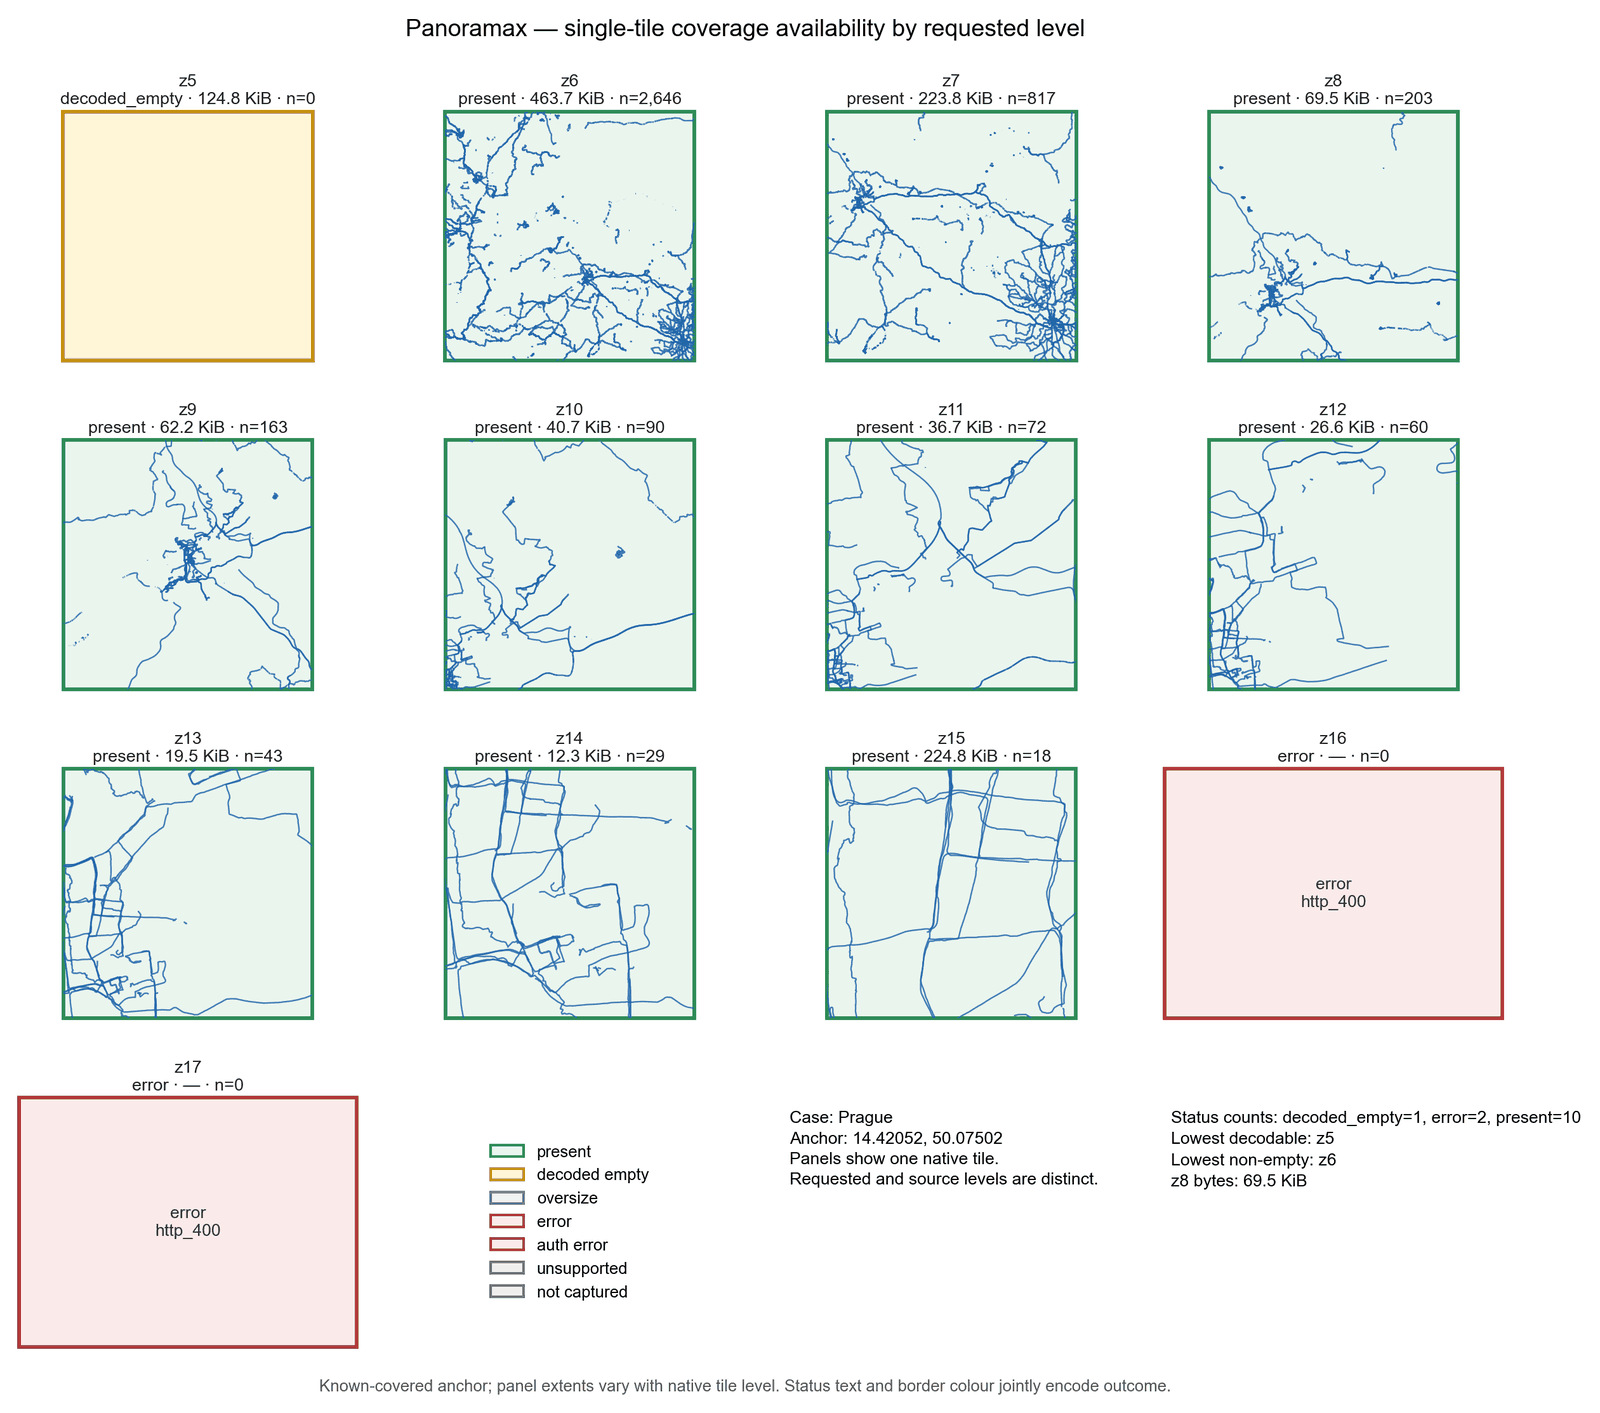

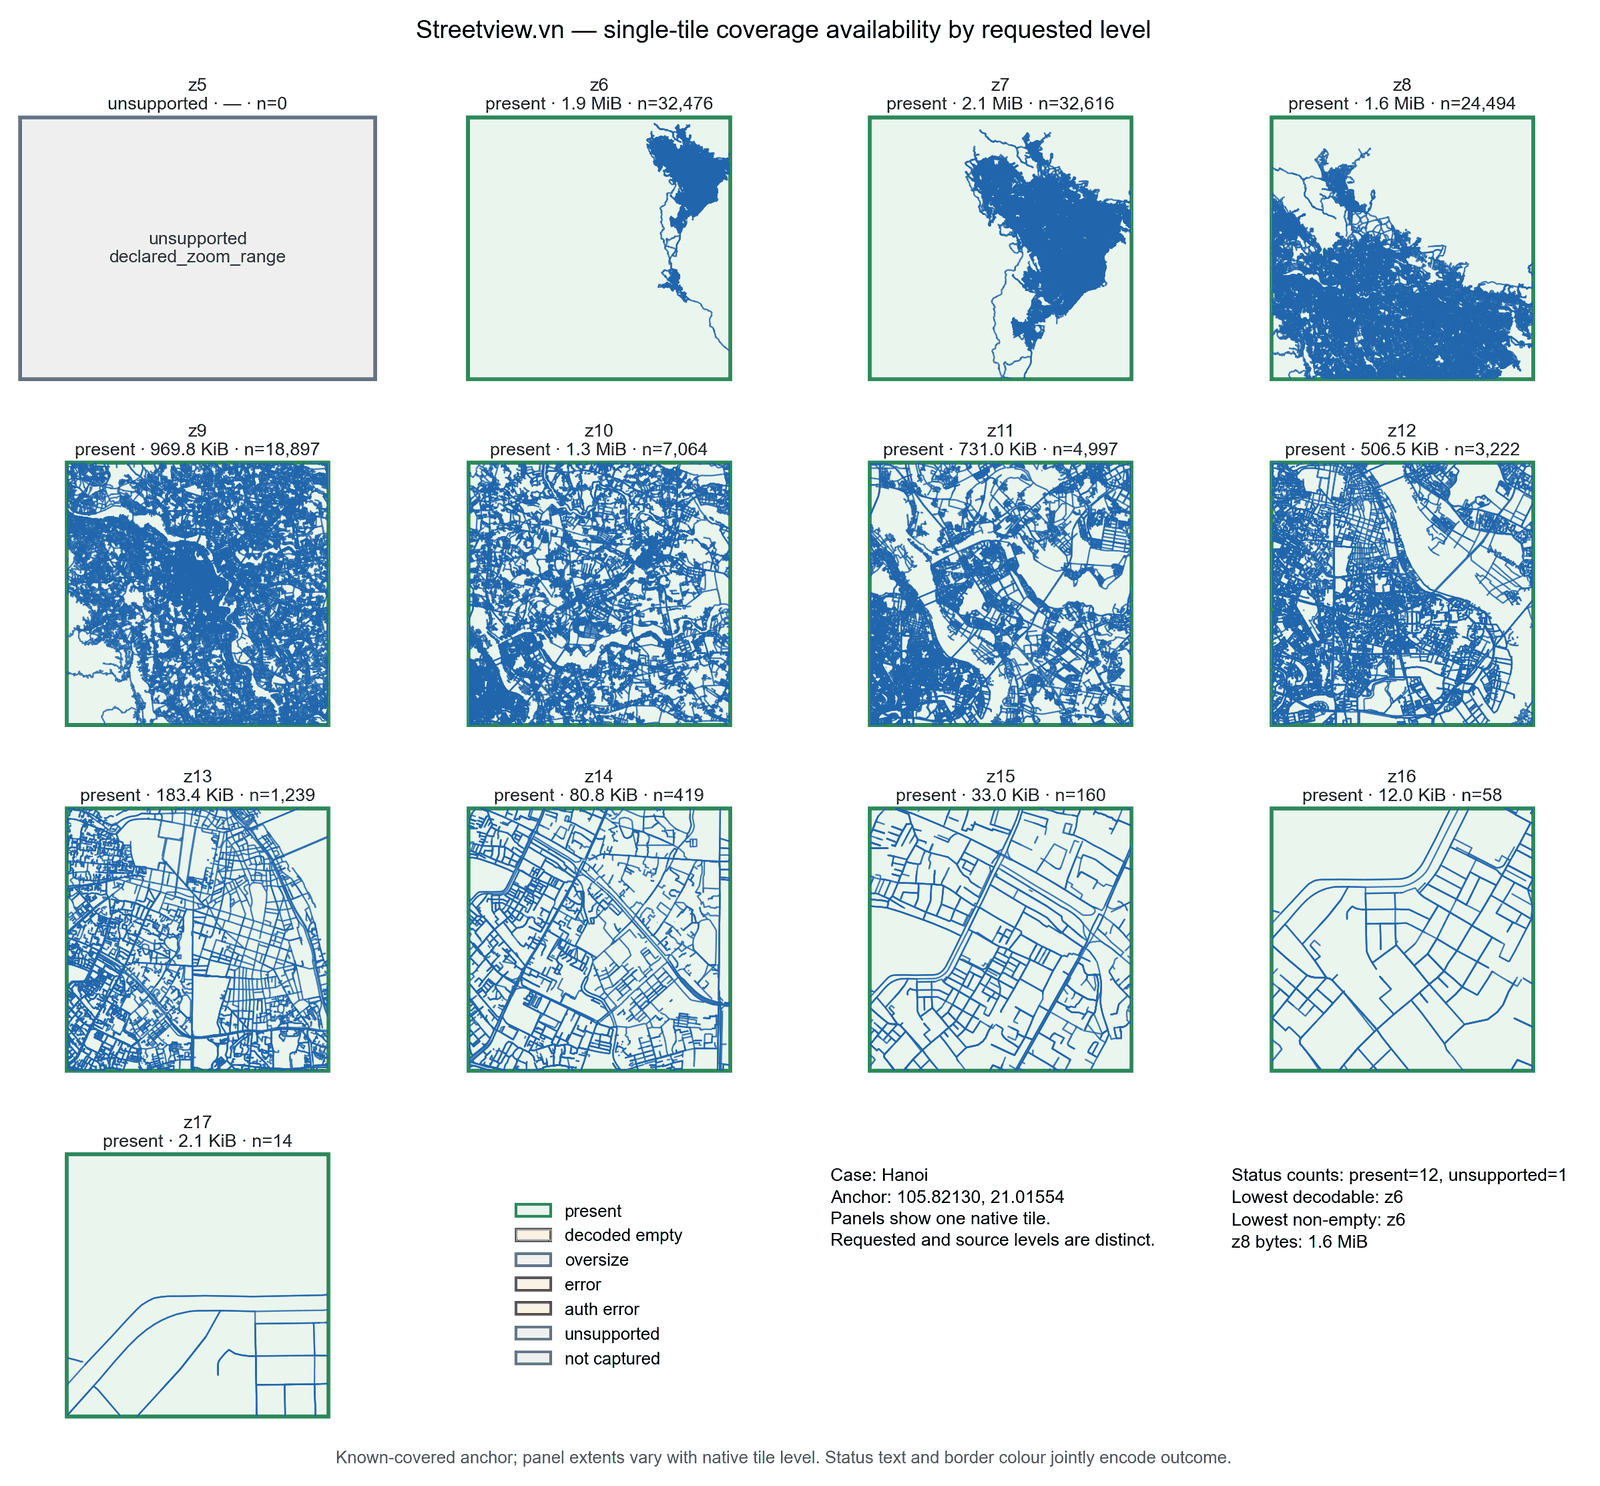

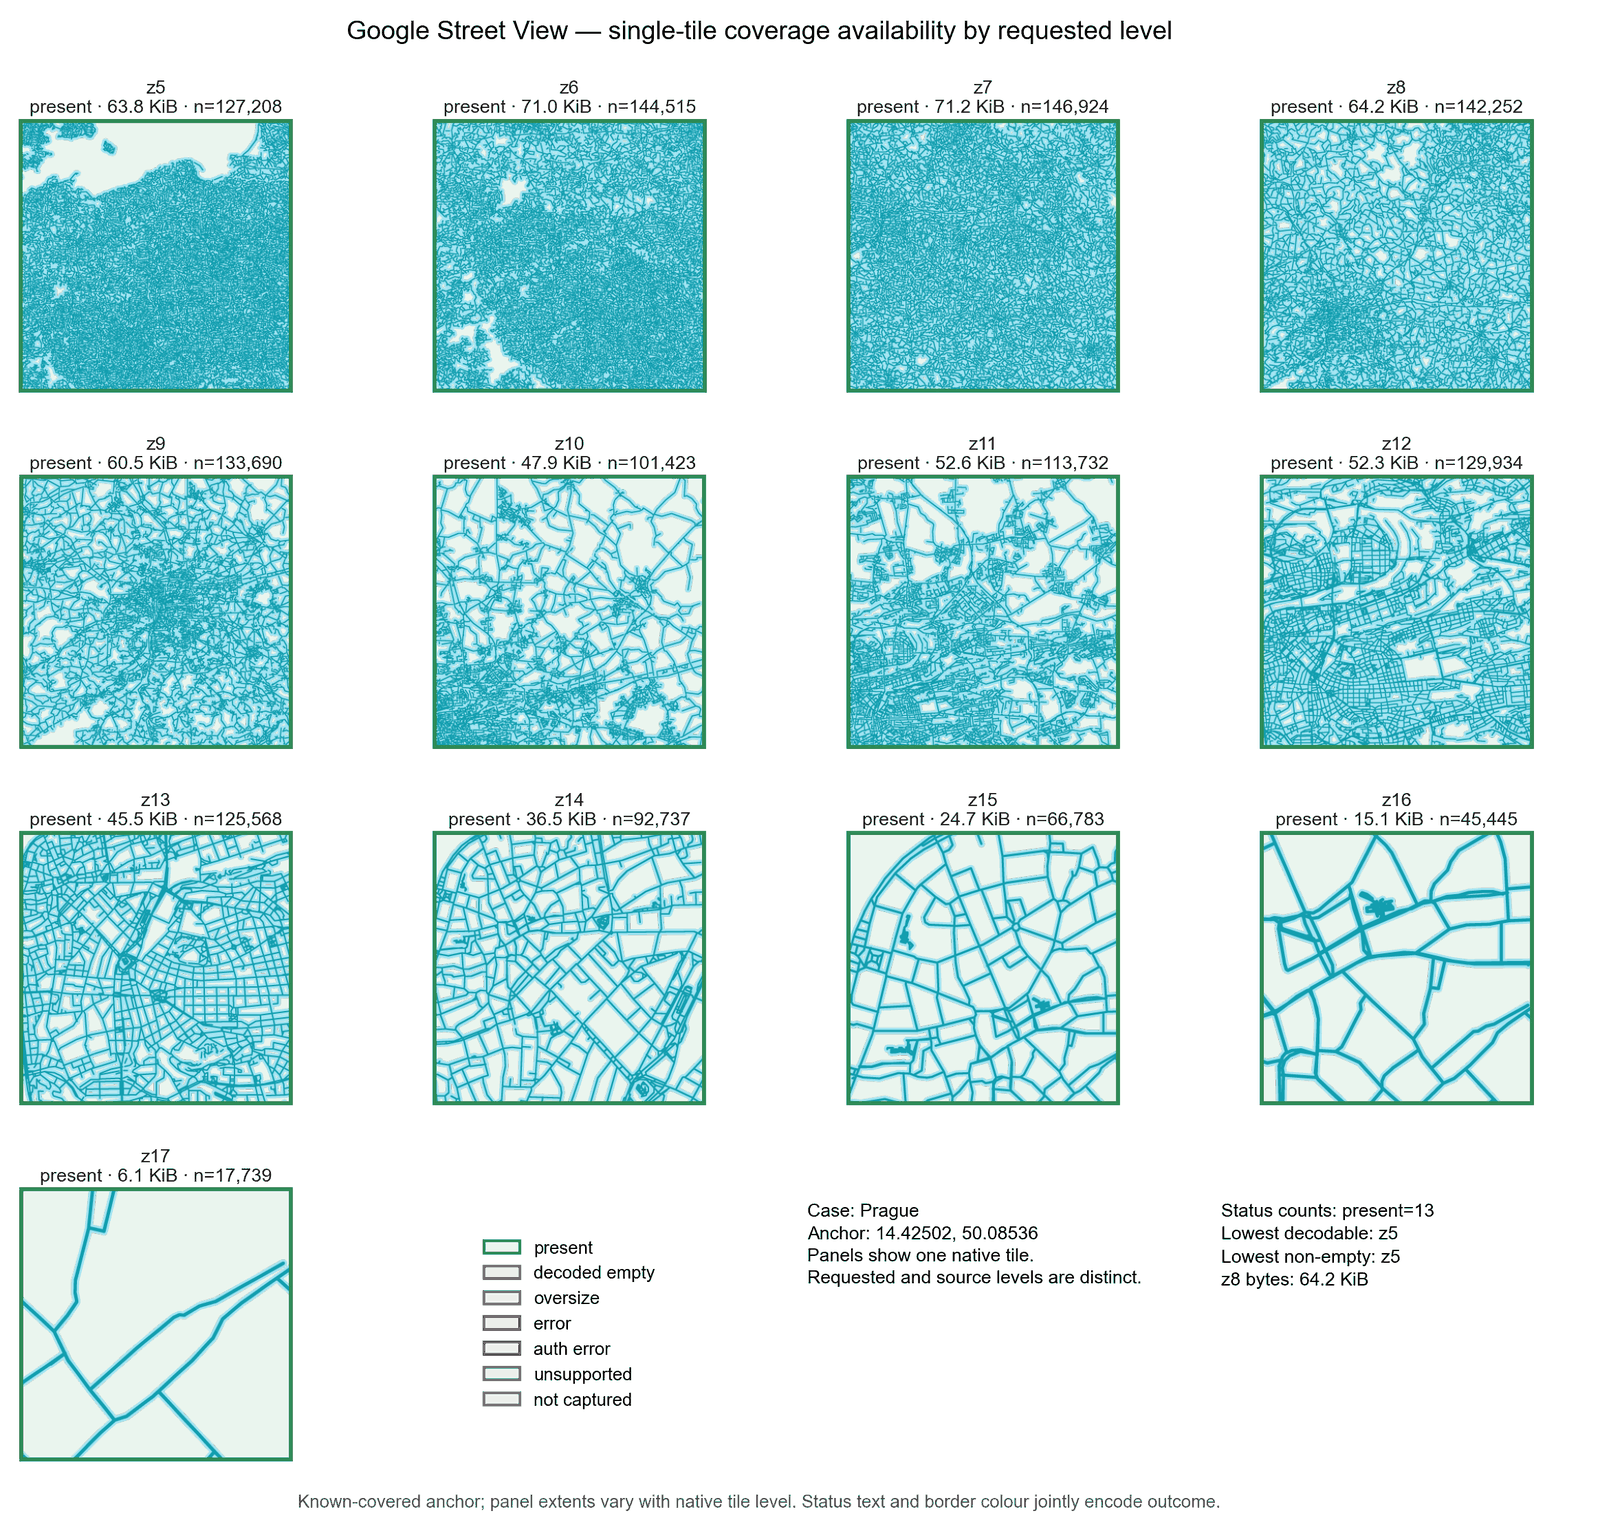

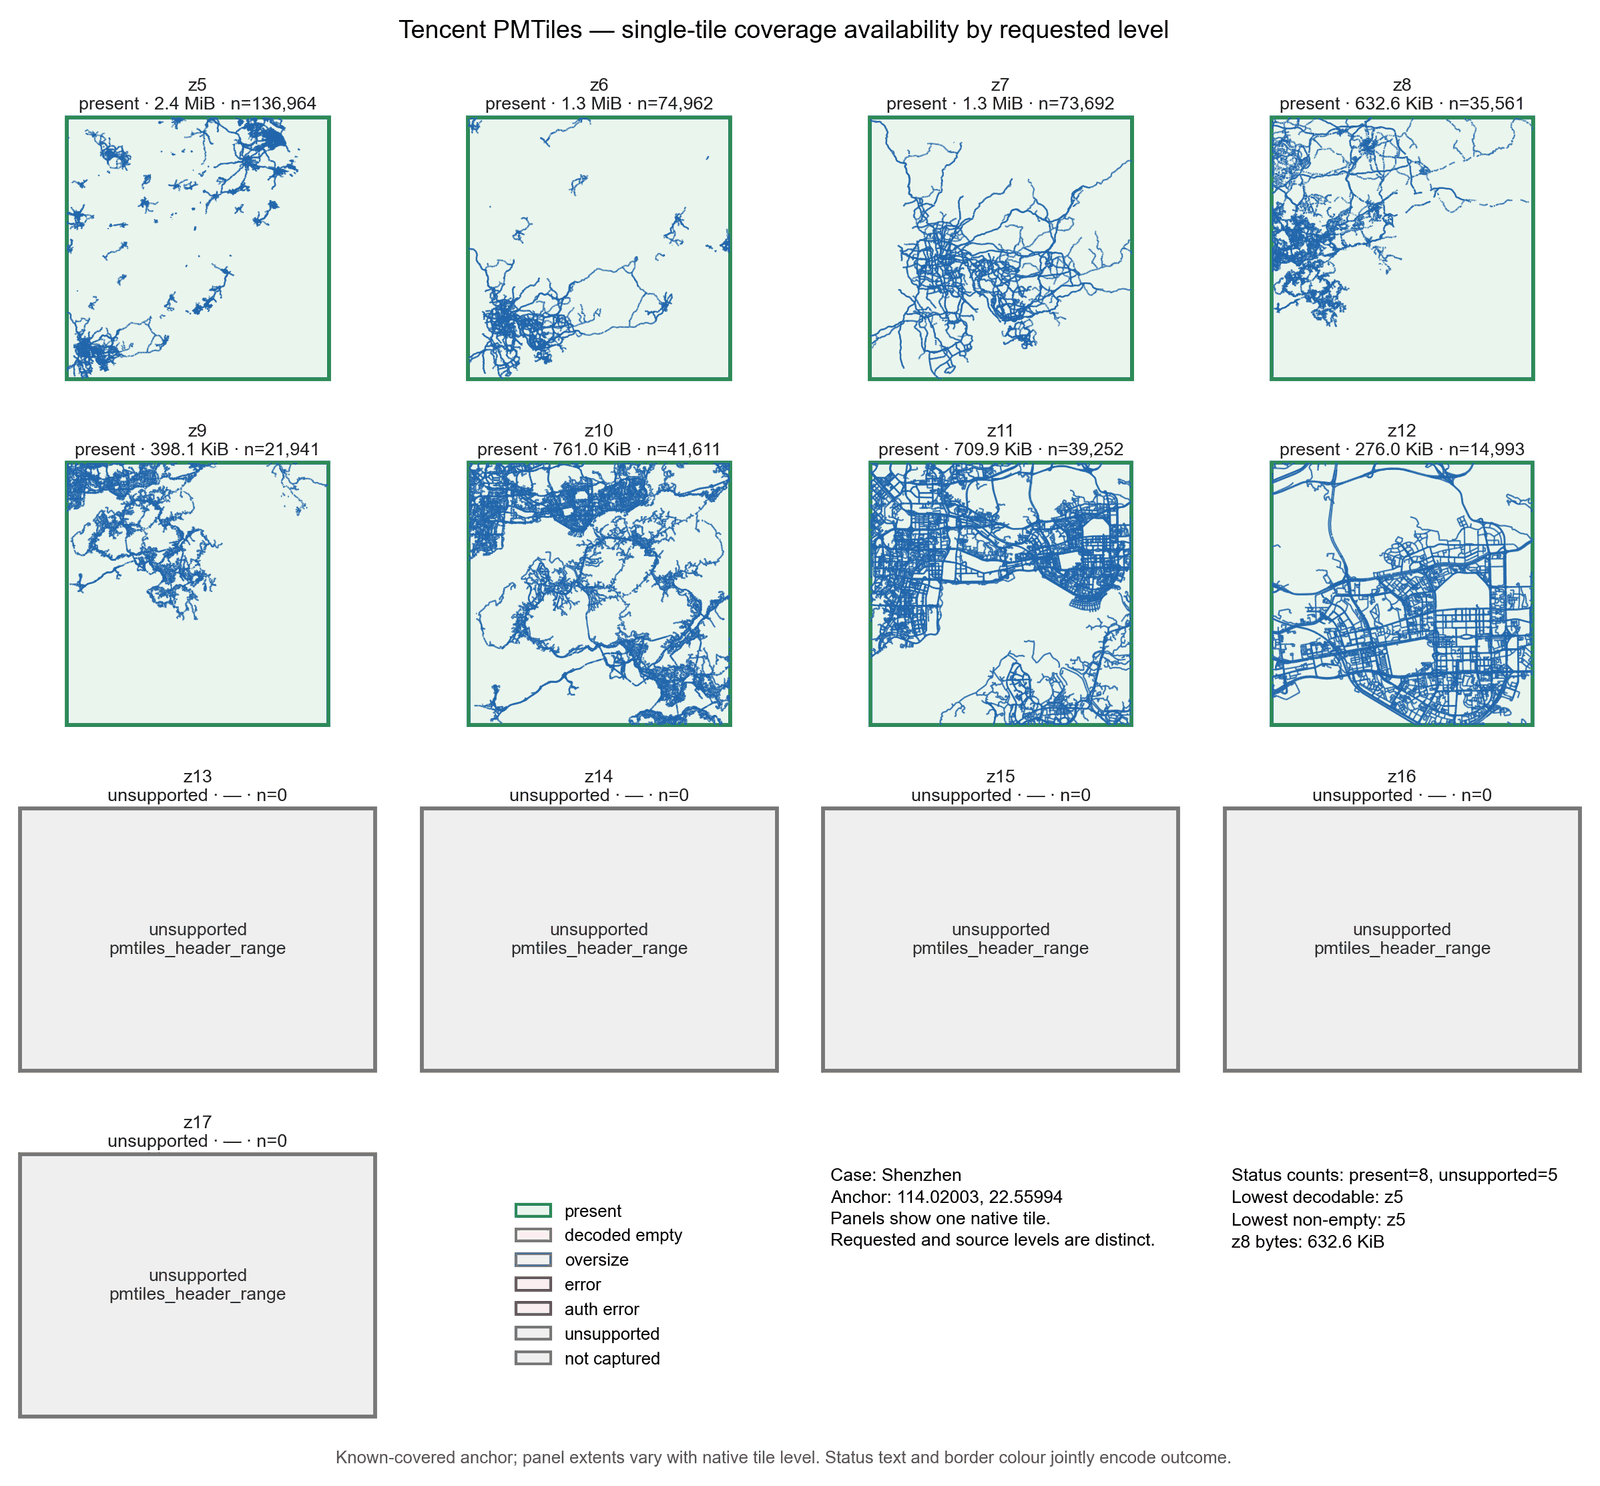

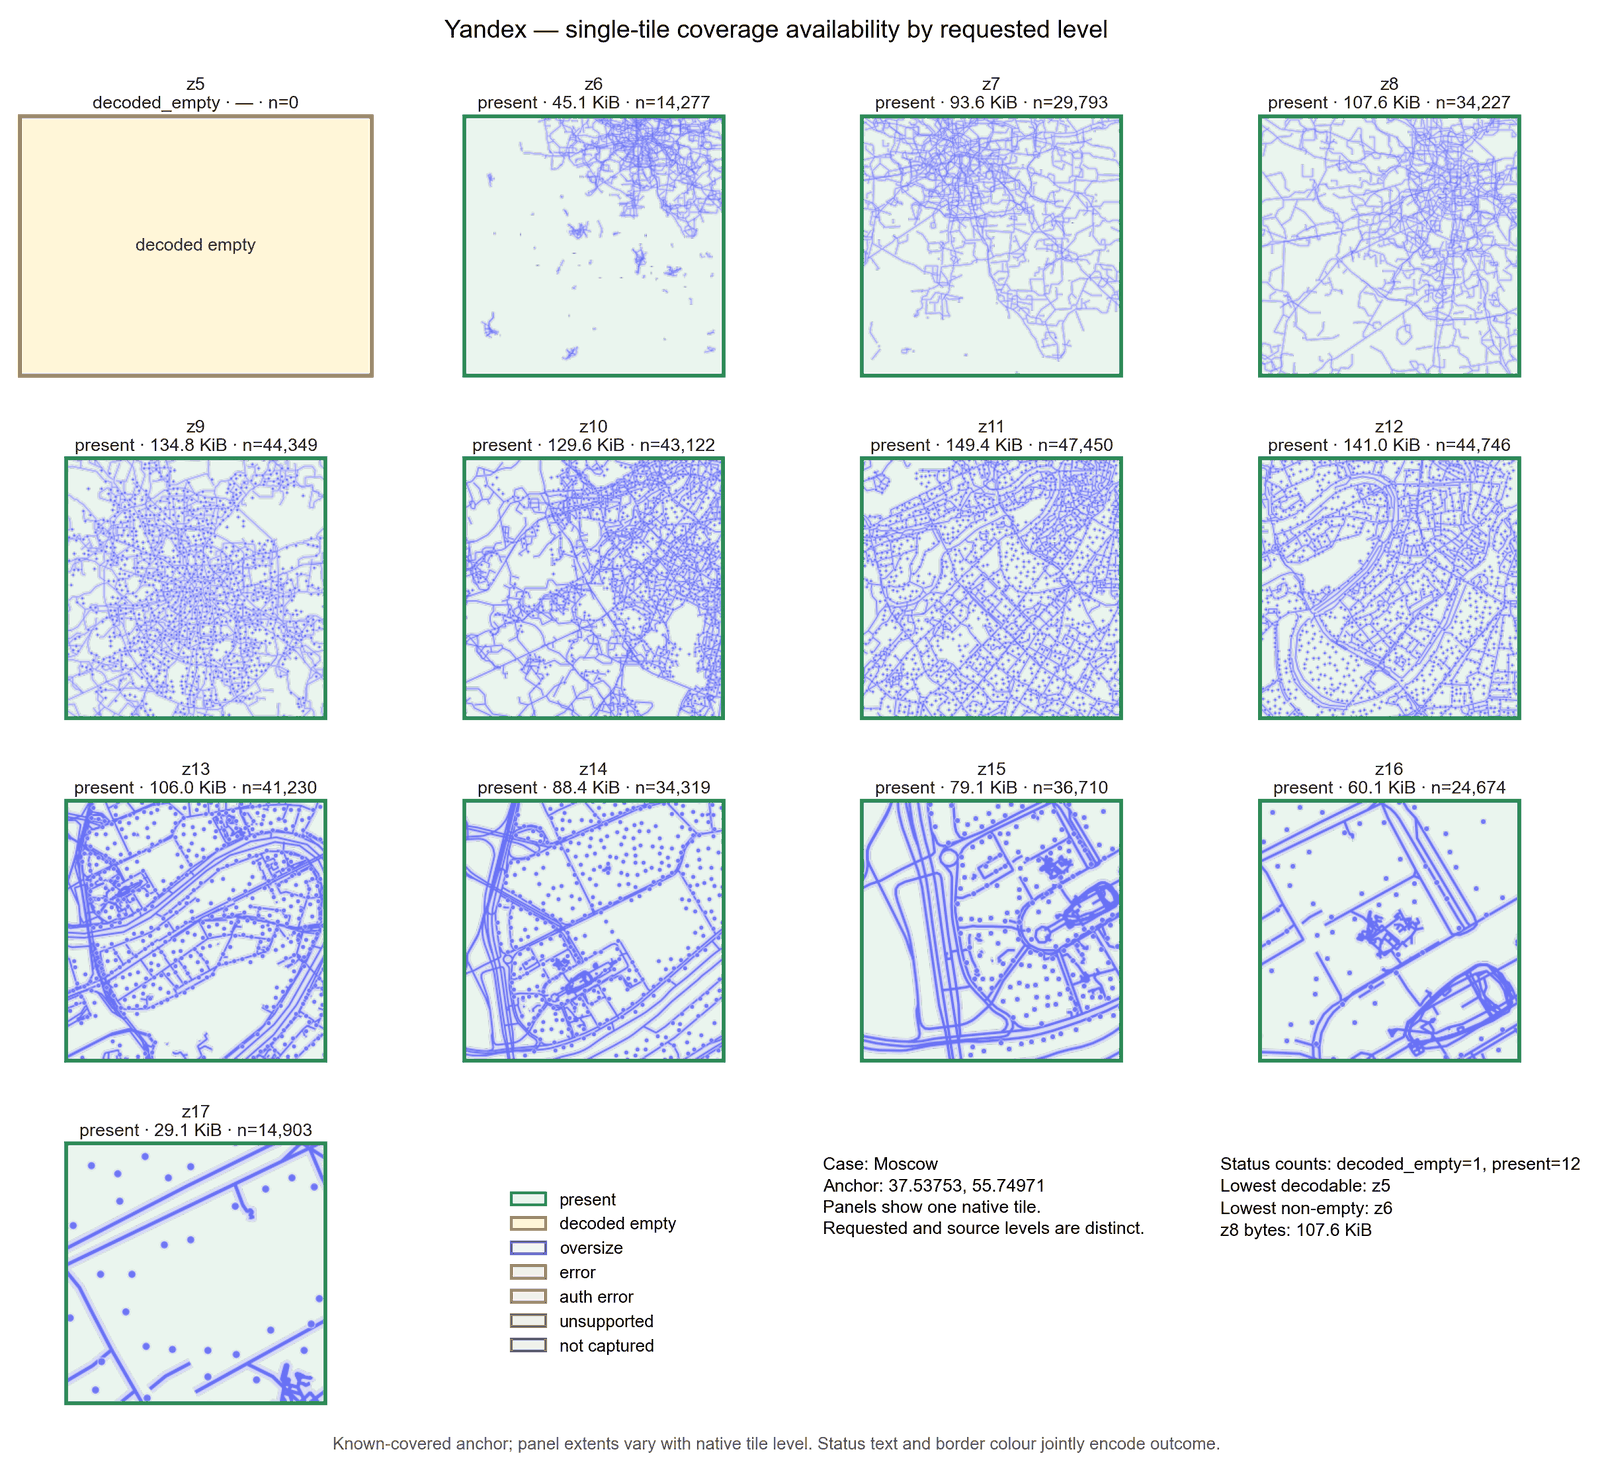

In [12]:
multiscale_reference_paths = sorted(REFERENCE_FIGURE_ROOT.glob("multiscale_*.png"))
if SHOW_REFERENCE_MAPS and multiscale_reference_paths:
    for path in multiscale_reference_paths:
        display(NotebookImage(filename=str(path)))
else:
    print(f"Embedded validated multiscale plates: {len(multiscale_reference_paths)} staged for this execution.")

,requested_level,status,source_kind,tile_count,record_count,plotted_record_count,error_count
0,5,unsupported,NaN,NaN,NaN,NaN,NaN
1,6,unsupported,NaN,NaN,NaN,NaN,NaN
2,7,rendered,vector_mvt,1.0,305248.0,43607.0,0.0
3,8,rendered,vector_mvt,1.0,305248.0,43607.0,0.0
4,9,rendered,vector_mvt,1.0,305248.0,43607.0,0.0
5,10,rendered,vector_mvt,1.0,288726.0,48121.0,0.0
6,11,rendered,vector_mvt,1.0,274114.0,45686.0,0.0
7,12,rendered,vector_mvt,1.0,116785.0,38929.0,0.0
8,13,rendered,vector_mvt,1.0,11496.0,11496.0,0.0
9,14,rendered,vector_mvt,1.0,3156.0,3156.0,0.0


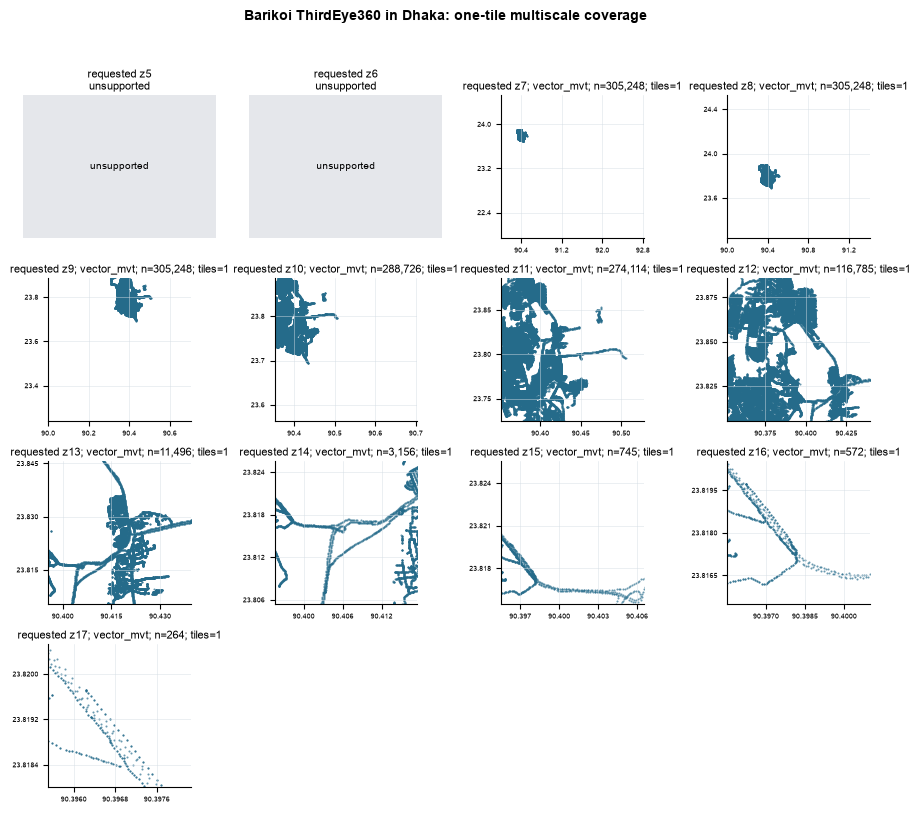

In [13]:
def multiscale_registry_manifest(provider_key, requested_level):
    namespace = PROVIDERS[provider_key].output_namespace
    run_label = f"multiscale_{provider_key}_l{requested_level}_subbox_00"
    return OUTPUT_ROOT / namespace / run_label / "manifest.json"


def multiscale_tencent_manifest(provider_key, requested_level):
    run_label = f"multiscale_{provider_key}_l{requested_level}_subbox_00"
    return OUTPUT_ROOT / provider_key / run_label / "manifest.json"


def render_multiscale_provider(provider_key: str):
    case = multiscale_case(provider_key)
    bbox = multiscale_probe_bbox(case)
    rows = zoom_plan_df.loc[zoom_plan_df["provider"].eq(provider_key)].set_index("requested_level")
    fig, axes = plt.subplots(4, 4, figsize=(9.2, 8.2), squeeze=False)
    for ax, requested_level in zip(axes.flat, MULTISCALE_LEVELS):
        row = rows.loc[requested_level]
        prefix = "L" if provider_key == "kakao" else "z"
        level_label = f"requested {prefix}{requested_level}"
        rendered = False
        if provider_key in PROVIDERS:
            path = multiscale_registry_manifest(provider_key, requested_level)
            if path.exists():
                result = load_result_from_manifest(path)
                plot_result(
                    ax,
                    result,
                    bbox=result_tile_bbox(result),
                    label=PROVIDER_LABELS[provider_key],
                    level_label=level_label,
                )
                rendered = True
        elif provider_key == TENCENT_KEY:
            path = multiscale_tencent_manifest(provider_key, requested_level)
            if path.exists():
                plot_result(
                    ax,
                    load_result_from_manifest(path),
                    bbox=bbox,
                    label=PROVIDER_LABELS[provider_key],
                    level_label=level_label,
                )
                rendered = True
        if not rendered:
            status = row["plan_status"].replace("_", " ")
            status_color = status_colors[status_index[row["plan_status"]]]
            ax.set_facecolor(status_color)
            ax.set_title(f"{level_label}\n{status}", fontsize=8, pad=4)
            ax.text(0.5, 0.5, status, transform=ax.transAxes, ha="center", va="center", color="#3F4B55")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
    for ax in axes.flat[len(MULTISCALE_LEVELS) :]:
        ax.axis("off")
    fig.suptitle(
        f"{PROVIDER_LABELS[provider_key]} in {case.area}: single-tile multiscale comparison",
        fontsize=10,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig


async def capture_barikoi_multiscale_and_cleanup():
    provider_key = "barikoi"
    rows = zoom_plan_df.loc[zoom_plan_df["provider"].eq(provider_key)].set_index("requested_level")
    fig, axes = plt.subplots(4, 4, figsize=(9.2, 8.2), squeeze=False)
    audit_rows = []
    for ax, requested_level in zip(axes.flat, MULTISCALE_LEVELS):
        row = rows.loc[requested_level]
        if row["plan_status"] == "unsupported":
            ax.set_facecolor(status_colors[status_index["unsupported"]])
            ax.text(0.5, 0.5, "unsupported", transform=ax.transAxes, ha="center", va="center")
            ax.set_title(f"requested z{requested_level}\nunsupported", fontsize=8, pad=4)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            audit_rows.append({"requested_level": requested_level, "status": "unsupported"})
            continue

        result = None
        try:
            manifest_path = multiscale_registry_manifest(provider_key, requested_level)
            if manifest_path.exists():
                result = load_result_from_manifest(manifest_path)
            else:
                batch_result = await acquire_multiscale_probe(provider_key, requested_level)
                result = batch_result["results"][0]
            summary = plot_result(
                ax,
                result,
                bbox=result_tile_bbox(result),
                label="",
                level_label=f"requested z{requested_level}",
                max_plot_records=50_000,
                show_axis_labels=False,
            )
            audit_rows.append({"requested_level": requested_level, "status": "rendered", **summary})
        except Exception as exc:
            ax.set_facecolor("#FBEAEA")
            ax.text(0.5, 0.5, type(exc).__name__, transform=ax.transAxes, ha="center", va="center")
            ax.set_title(f"requested z{requested_level}\nfetch error", fontsize=8, pad=4)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            audit_rows.append({"requested_level": requested_level, "status": "error", "error_type": type(exc).__name__})
        finally:
            if result is not None:
                shutil.rmtree(Path(result["output_dir"]), ignore_errors=False)

    for ax in axes.flat[len(MULTISCALE_LEVELS) :]:
        ax.axis("off")
    fig.suptitle(
        "Barikoi ThirdEye360 in Dhaka: one-tile multiscale coverage",
        fontsize=10,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, pd.DataFrame(audit_rows)


if CAPTURE_BARIKOI_MAPS:
    if not ALLOW_NETWORK:
        raise RuntimeError("SVI_CAPTURE_BARIKOI_MAPS=1 also requires SVI_NOTEBOOK_ALLOW_NETWORK=1.")
    barikoi_figure, barikoi_capture_df = await capture_barikoi_multiscale_and_cleanup()
    display(barikoi_capture_df)
    plt.show()
else:
    render_multiscale_provider(FOCAL_MULTISCALE_PROVIDER)
    plt.show()

In [14]:
implemented = set(PROVIDERS) | {TENCENT_KEY, MAPPLS_KEY}
compared = set(case_df["provider_key"])
audited = set(zoom_plan_df["provider"])
assert implemented == compared == audited
assert len(area_plan_df) == len(case_df)
assert len(zoom_plan_df) == 16 * len(MULTISCALE_LEVELS)
assert not RUN_ACQUISITIONS and not RUN_MULTISCALE_PROBES
print(
    f"Validated {len(compared)} providers, {len(AREA_COMPARISON_CASES)} same-area cases, "
    f"and {len(zoom_plan_df)} multiscale plan rows. "
    f"Reference maps displayed: {len(area_reference_paths) + len(multiscale_reference_paths)}; "
    f"Barikoi live capture: {CAPTURE_BARIKOI_MAPS}."
)

Validated 16 providers, 10 same-area cases, and 208 multiscale plan rows. Reference maps displayed: 24; Barikoi live capture: True.
